In [53]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, average_precision_score, accuracy_score
from collections import Counter
from sklearn.model_selection import RandomizedSearchCV

# plotting defaults (simple)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


In [54]:
# data loading
txn = pd.read_csv(r"C:\Users\Crown Tech\Documents\PROJECTS\DSTT\train_transaction.csv")
iden = pd.read_csv(r"C:\Users\Crown Tech\Documents\PROJECTS\DSTT\train_identity.csv")

print("Transaction shape:", txn.shape)
print("Identity shape:", iden.shape)

# quick peek
display(txn.head())
display(iden.head())


Transaction shape: (590540, 394)
Identity shape: (144233, 41)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [55]:
# All column names in both files
print("Transaction columns:", txn.columns.tolist()[:10], "...")  # showing first 10 only for short display
print("Total transaction columns:", len(txn.columns))

print("\nIdentity columns:", iden.columns.tolist()[:10], "...")
print("Total identity columns:", len(iden.columns))


Transaction columns: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5'] ...
Total transaction columns: 394

Identity columns: ['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09'] ...
Total identity columns: 41


In [56]:
#Merge on the basis of same column
df = txn.merge(iden, on='TransactionID', how='left')
print("Merged shape:", df.shape)


Merged shape: (590540, 434)


In [57]:
#cell 5 cg=hecking duplicates
print("Duplicate TransactionID count: ", df['TransactionID'].duplicated().sum())
print(f"Total duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate TransactionIDs: {df['TransactionID'].duplicated().sum()}")

Duplicate TransactionID count:  0
Total duplicate rows: 0
Duplicate TransactionIDs: 0


In [58]:
#cell 6 check missing values and columns with highest missing
# Check missing values in all columns
print("=== MISSING VALUES CHECK ===")

# Count missing values in each column
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

# Create a summary
missing_summary = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percent': missing_percent
})

# Show columns with missing values (sorted by highest missing %)
columns_with_missing = missing_summary[missing_summary['Missing_Count'] > 0]
print(f"Columns with missing values: {len(columns_with_missing)}")

# Show the worst offenders first
print("\nTop 20 columns with highest missing values:")
print(columns_with_missing.sort_values('Missing_Percent', ascending=False).head(50))

=== MISSING VALUES CHECK ===
Columns with missing values: 414

Top 20 columns with highest missing values:
       Missing_Count  Missing_Percent
id_24         585793        99.196159
id_25         585408        99.130965
id_07         585385        99.127070
id_08         585385        99.127070
id_21         585381        99.126393
id_26         585377        99.125715
id_27         585371        99.124699
id_23         585371        99.124699
id_22         585371        99.124699
dist2         552913        93.628374
D7            551623        93.409930
id_18         545427        92.360721
D13           528588        89.509263
D14           528353        89.469469
D12           525823        89.041047
id_03         524216        88.768923
id_04         524216        88.768923
D6            517353        87.606767
id_33         517251        87.589494
id_10         515614        87.312290
id_09         515614        87.312290
D8            515614        87.312290
D9            51561

In [59]:
# Check outliers in ALL columns and show summary table
print("OUTLIER SUMMARY FOR ALL COLUMNS")

# Get numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'isFraud']

# Calculate outliers for all numeric columns
outlier_list = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_percent = (len(outliers) / len(df)) * 100
    
    outlier_list.append({
        'Column': col,
        'Outlier_Count': len(outliers),
        'Outlier_Percent': outlier_percent
    })

# Create summary table sorted by most outliers
outlier_df = pd.DataFrame(outlier_list)
outlier_df = outlier_df.sort_values('Outlier_Percent', ascending=False)

print("Outlier Summary Table:")
print(outlier_df.head(20))  # Show top 20 columns with most outliers

OUTLIER SUMMARY FOR ALL COLUMNS
Outlier Summary Table:
    Column  Outlier_Count  Outlier_Percent
18      C8         142873        24.193619
342   V303         141029        23.881363
343   V304         140698        23.825312
341   V302         140337        23.764182
14      C4         138657        23.479697
20     C10         137098        23.215701
136    V97         136013        23.031971
167   V128         136013        23.031971
330   V291         127599        21.607173
326   V287         123665        20.941003
351   V312         123665        20.941003
353   V314         115998        19.642700
101    V62         114931        19.462018
59     V20         112538        19.056795
100    V61         109262        18.502049
58     V19         108802        18.424154
347   V308         105496        17.864328
122    V83         104757        17.739188
354   V315         102198        17.305856
328   V289         102198        17.305856


In [60]:
#As we will start cleaning now, making a copy for safety.
df_copy=df.copy()

In [61]:
# Select numeric columns only
numeric_cols = df_copy.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col_to_exclude in ['isFraud', 'TransactionAmt']:
    if col_to_exclude in numeric_cols:
        numeric_cols.remove(col_to_exclude)

print(f"Numeric columns count (excluding 'isFraud' and 'TransactionAmt'): {len(numeric_cols)}")


# Function to cap outliers using IQR
def cap_outliers(col):
    Q1 = df_copy[col].quantile(0.25)
    Q3 = df_copy[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Count outliers before
    before = ((df_copy[col] < lower) | (df_copy[col] > upper)).sum()

    # Apply capping
    df_copy[col] = df_copy[col].clip(lower, upper)

    # Outlier count after capping
    after = ((df_copy[col] < lower) | (df_copy[col] > upper)).sum()
    
    print(f"{col}: Outliers before = {before}, after = {after}")

# Apply to each numeric column
for col in numeric_cols:
    try:
        cap_outliers(col)
    except:
        print(f" Skipped column: {col} (error handling outliers)")
#Apply log transformation to TransactionAmt
df_copy['TransactionAmt'] = np.log1p(df_copy['TransactionAmt'])
print("\nLog transformation applied directly to 'TransactionAmt'.")
print("\n Outlier handling completed for all numeric columns.")


Numeric columns count (excluding 'isFraud' and 'TransactionAmt'): 401
TransactionID: Outliers before = 0, after = 0
TransactionDT: Outliers before = 0, after = 0
card1: Outliers before = 0, after = 0
card2: Outliers before = 0, after = 0
card3: Outliers before = 67688, after = 0
card5: Outliers before = 0, after = 0
addr1: Outliers before = 369, after = 0
addr2: Outliers before = 4353, after = 0
dist1: Outliers before = 39981, after = 0
dist2: Outliers before = 4710, after = 0
C1: Outliers before = 59535, after = 0
C2: Outliers before = 62214, after = 0
C3: Outliers before = 2429, after = 0
C4: Outliers before = 138657, after = 0
C5: Outliers before = 60446, after = 0
C6: Outliers before = 78329, after = 0
C7: Outliers before = 67398, after = 0
C8: Outliers before = 142873, after = 0
C9: Outliers before = 42629, after = 0
C10: Outliers before = 137098, after = 0
C11: Outliers before = 74844, after = 0
C12: Outliers before = 101341, after = 0
C13: Outliers before = 75631, after = 0
C14:

Starting shape: (590540, 434)
>80% DROP: 74
≤80% IMPUTE ONLY: 340


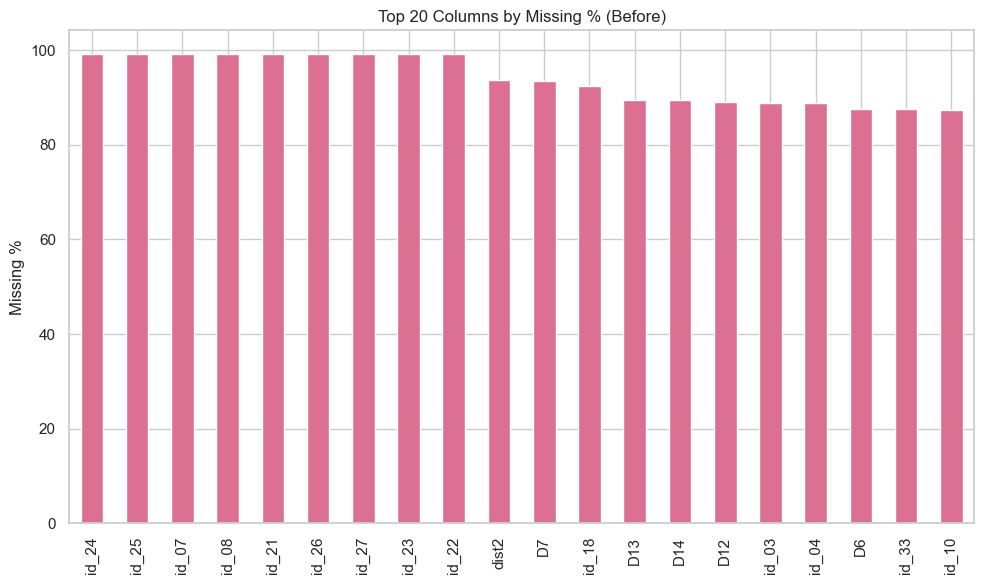

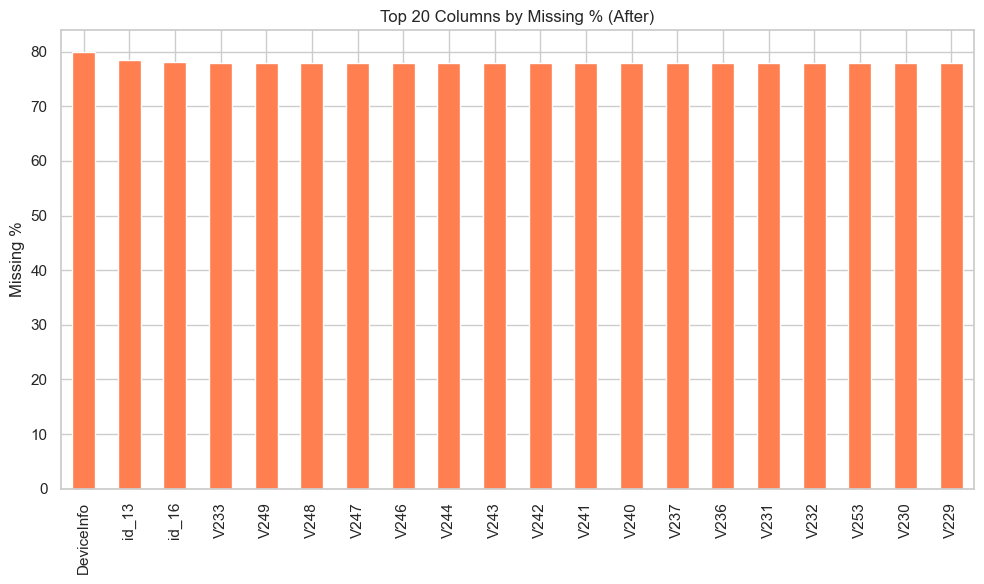

In [62]:
# -----------------------------
# Missing Value Handling (Without Flags)
# -----------------------------
from sklearn.impute import SimpleImputer
from pandas.api.types import is_numeric_dtype
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Starting shape:", df_copy.shape)

# Compute missing percentage
missing_percent = (df_copy.isnull().sum() / len(df_copy)) * 100

# Categorize columns
drop_cols = missing_percent[missing_percent > 80].index.tolist()
impute_cols = missing_percent[(missing_percent > 0) & (missing_percent <= 80)].index.tolist()

print(f">80% DROP: {len(drop_cols)}")
print(f"≤80% IMPUTE ONLY: {len(impute_cols)}")

# Drop columns >80%
df_copy.drop(columns=drop_cols, inplace=True)



# ---- Visualization: Before/After Missing % ----
plt.figure(figsize=(10,6))
missing_percent.sort_values(ascending=False).head(20).plot(kind='bar', color='palevioletred')
plt.title("Top 20 Columns by Missing % (Before)")
plt.ylabel("Missing %")
plt.tight_layout()
plt.show()

after_missing = (df_copy.isnull().sum() / len(df_copy)) * 100
remaining_missing = after_missing[after_missing > 0]

if len(remaining_missing) > 0:
    plt.figure(figsize=(10,6))
    remaining_missing.sort_values(ascending=False).head(20).plot(kind='bar', color='coral')
    plt.title("Top 20 Columns by Missing % (After)")
    plt.ylabel("Missing %")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values remain after processing.")


In [63]:
print("Shape before dropping irrelevant columns :", df_copy.shape)
y_col = "isFraud"

# Columns excluding target
X_cols = [c for c in df_copy.columns if c != y_col]

Shape before dropping irrelevant columns : (590540, 360)


In [64]:
from sklearn.feature_selection import VarianceThreshold

In [65]:
print("Shape before dropping irrelevant columns :", df_copy.shape)

y_col = "isFraud"

# Columns excluding target
X_cols = [c for c in df_copy.columns if c != y_col]

Shape before dropping irrelevant columns : (590540, 360)


In [66]:
const_cols = [col for col in X_cols if df_copy[col].nunique() <= 1]

if const_cols:
    print(f"\nConstant Columns to Drop: {len(const_cols)}")
    print(const_cols)
    df_copy.drop(columns=const_cols, inplace=True, errors='ignore')
else:
    print("\n No constant columns found.")



Constant Columns to Drop: 265
['card3', 'addr2', 'C3', 'C4', 'C7', 'C8', 'C10', 'C12', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V31', 'V32', 'V33', 'V34', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V50', 'V51', 'V52', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V71', 'V72', 'V73', 'V74', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V92', 'V93', 'V94', 'V95', 'V97', 'V98', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', 'V113', 'V114', 'V115', 'V116', 'V117', 'V118', 'V119', 'V120', 'V121', 'V122', 'V123', 'V124', 'V125', 'V126', 'V128', 'V129', 'V131', 'V132', 'V133', 'V134', 'V135', 'V136', 'V137', 'V167', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V177', 

In [67]:
from sklearn.feature_selection import VarianceThreshold

# Drop target column
X_temp = df_copy.drop(columns=[y_col])

# Select numeric columns only
numeric_cols = X_temp.select_dtypes(include=['int64', 'float64']).columns
X_numeric = X_temp[numeric_cols]

# Apply VarianceThreshold
selector = VarianceThreshold(threshold=0.01)  # <=1% variance
selector.fit(X_numeric)

# Get low-variance columns
low_var_cols = X_numeric.columns[~selector.get_support()].tolist()

if low_var_cols:
    print(f"\nLow Variance Columns Dropped: {len(low_var_cols)}")
    print(low_var_cols[:20])
    df_copy.drop(columns=low_var_cols, inplace=True, errors='ignore')
else:
    print("\nNo low-variance columns found.")




No low-variance columns found.


In [68]:
# Drop target column
X_temp = df_copy.drop(columns=[y_col])

# Keep numeric columns only
numeric_cols = X_temp.select_dtypes(include=['int64', 'float64']).columns
X_numeric = X_temp[numeric_cols]

# Absolute correlation
corr_matrix = X_numeric.corr().abs()

# Keep upper triangle only
upper = corr_matrix.where(
    ~np.tril(np.ones(corr_matrix.shape), k=0).astype(bool)
)

# Features to drop
high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Highly correlated columns to drop: {len(high_corr_cols)}")
print(high_corr_cols[:20])

df_copy.drop(columns=high_corr_cols, inplace=True, errors='ignore')


Highly correlated columns to drop: 6
['TransactionDT', 'V11', 'V30', 'V49', 'V70', 'V91']


In [69]:
print("\nFinal shape after feature reduction:", df_copy.shape)



Final shape after feature reduction: (590540, 89)


In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [71]:
#Split chronologically for training

# Ensure TransactionDT exists (from original df)
df_copy['TransactionDT'] = df['TransactionDT']

# Sort chronologically
df_copy = df_copy.sort_values('TransactionDT').reset_index(drop=True)

# Split index (e.g., 80% train, 20% test)
split_idx = int(len(df_copy) * 0.8)

train_df = df_copy.iloc[:split_idx].copy()
test_df  = df_copy.iloc[split_idx:].copy()

# Separate features and target
y_train = train_df['isFraud']
X_train = train_df.drop(columns=['isFraud', 'TransactionDT','TransactionID'])

y_test = test_df['isFraud']
X_test = test_df.drop(columns=['isFraud', 'TransactionDT','TransactionID'])

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (472432, 87) Test shape: (118108, 87)


In [72]:
# ---- Imputation ----

from sklearn.impute import SimpleImputer
from pandas.api.types import is_numeric_dtype

# Keep only valid columns
impute_cols = [col for col in impute_cols if col in X_train.columns]

num_cols = [col for col in impute_cols if is_numeric_dtype(X_train[col])]
cat_cols = [col for col in impute_cols if not is_numeric_dtype(X_train[col])]

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# FIT on train
if num_cols:
    X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
if cat_cols:
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])

# TRANSFORM test
if num_cols:
    X_test[num_cols] = num_imputer.transform(X_test[num_cols])
if cat_cols:
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

print("Imputation complete safely")
print("Missing in train:", X_train.isnull().sum().sum())
print("Missing in test:", X_test.isnull().sum().sum())

Imputation complete safely
Missing in train: 0
Missing in test: 0


In [73]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Display original shapes
print("\n ORIGINAL DATA SHAPES:")
print(f"   • X_train: {X_train.shape}")
print(f"   • X_test:  {X_test.shape}")
print(f"   • y_train: {y_train.shape}")
print(f"   • y_test:  {y_test.shape}")

# Separate numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"\n FEATURE BREAKDOWN:")
print(f"   • Numeric features: {len(numeric_cols)}")
print(f"   • Categorical features: {len(categorical_cols)}")
print(f"   • Total features: {len(numeric_cols) + len(categorical_cols)}")

# Initialize preprocessing objects
scaler = StandardScaler()
label_encoders = {}

# Create copies to preserve original data
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

print(" PROCESSING CATEGORICAL FEATURES (Real-world temporal split)...")

# Frequency encode categorical features FIRST
for col in categorical_cols:
    freq_map = X_train[col].astype(str).value_counts(normalize=True).to_dict()
    X_train_processed[col] = X_train[col].astype(str).map(freq_map).fillna(0)
    X_test_processed[col] = X_test[col].astype(str).map(freq_map).fillna(0)
    label_encoders[col] = freq_map

print("\n PROCESSING NUMERIC FEATURES...")

# Combine all numeric features: original + frequency-encoded
numeric_cols_after_fe = X_train_processed.select_dtypes(include=['int64','float64']).columns.tolist()

# Scale all numeric features (after frequency encoding)
X_train_processed[numeric_cols_after_fe] = scaler.fit_transform(X_train_processed[numeric_cols_after_fe])
X_test_processed[numeric_cols_after_fe] = scaler.transform(X_test_processed[numeric_cols_after_fe])

print(f"Scaled {len(numeric_cols_after_fe)} numeric features (original + frequency-encoded)")


print("\n PREPROCESSING COMPLETED!")
print(" FINAL DATA SHAPES:")
print(f"   • X_train_processed: {X_train_processed.shape}")
print(f"   • X_test_processed:  {X_test_processed.shape}")
print(f"   • y_train:           {y_train.shape} (unchanged)")
print(f"   • y_test:            {y_test.shape} (unchanged)")

print(f"\n DATA INTEGRITY CHECK:")
print(f"   • Train samples: {len(X_train_processed):,}")
print(f"   • Test samples:  {len(X_test_processed):,}")
print(f"   • Total samples: {len(X_train_processed) + len(X_test_processed):,}")
print(f"   • Features: {X_train_processed.shape[1]}")

print(f"\n SAMPLE STATISTICS (First 5 numeric columns):")
for col in numeric_cols[:5]:
    print(f"   • {col}: Train mean={X_train_processed[col].mean():.3f}, Test mean={X_test_processed[col].mean():.3f}")

print(f"\n READY FOR MODELING!")
print("   Next steps: Use X_train_processed, y_train for training")
print("               Use X_test_processed, y_test for evaluation")


 ORIGINAL DATA SHAPES:
   • X_train: (472432, 87)
   • X_test:  (118108, 87)
   • y_train: (472432,)
   • y_test:  (118108,)

 FEATURE BREAKDOWN:
   • Numeric features: 61
   • Categorical features: 26
   • Total features: 87
 PROCESSING CATEGORICAL FEATURES (Real-world temporal split)...

 PROCESSING NUMERIC FEATURES...
Scaled 87 numeric features (original + frequency-encoded)

 PREPROCESSING COMPLETED!
 FINAL DATA SHAPES:
   • X_train_processed: (472432, 87)
   • X_test_processed:  (118108, 87)
   • y_train:           (472432,) (unchanged)
   • y_test:            (118108,) (unchanged)

 DATA INTEGRITY CHECK:
   • Train samples: 472,432
   • Test samples:  118,108
   • Total samples: 590,540
   • Features: 87

 SAMPLE STATISTICS (First 5 numeric columns):
   • TransactionAmt: Train mean=-0.000, Test mean=0.002
   • card1: Train mean=0.000, Test mean=0.032
   • card2: Train mean=-0.000, Test mean=-0.010
   • card5: Train mean=-0.000, Test mean=-0.037
   • addr1: Train mean=-0.000, Tes

In [74]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(472432, 87)
(118108, 87)


In [75]:
#Baselines modeling

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_processed, y_train)
y_pred_log = log_model.predict(X_test_processed)
y_prob_log = log_model.predict_proba(X_test_processed)[:,1]

In [76]:

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)
y_prob_rf = rf_model.predict_proba(X_test_processed)[:,1]

In [77]:
#XGBOOST

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_processed, y_train)
y_pred_xgb = xgb_model.predict(X_test_processed)
y_prob_xgb = xgb_model.predict_proba(X_test_processed)[:,1]


C:\Users\Crown Tech\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:13:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [78]:
#LightGBM

lgb_model = LGBMClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
lgb_model.fit(X_train_processed, y_train)
y_pred_lgb = lgb_model.predict(X_test_processed)
y_prob_lgb = lgb_model.predict_proba(X_test_processed)[:,1]


[LightGBM] [Info] Number of positive: 16599, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.099099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6102
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 87
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035135 -> initscore=-3.312784
[LightGBM] [Info] Start training from score -3.312784



Logistic Regression Metrics:
Accuracy: 0.9701
ROC-AUC: 0.8466
PR-AUC: 0.3836

Classification Report:
              precision    recall  f1-score   support

           0     0.9732    0.9965    0.9847    114044
           1     0.7013    0.2293    0.3456      4064

    accuracy                         0.9701    118108
   macro avg     0.8372    0.6129    0.6652    118108
weighted avg     0.9638    0.9701    0.9627    118108



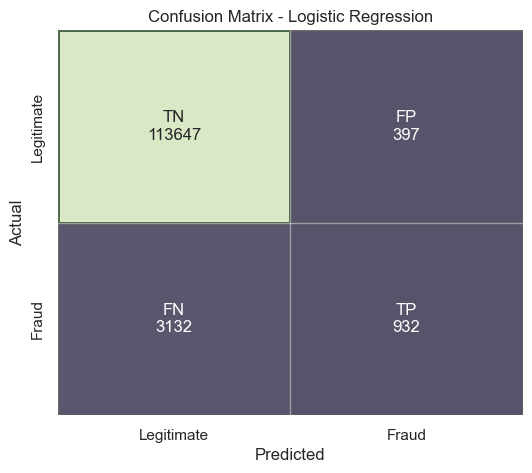


Random Forest Metrics:
Accuracy: 0.9736
ROC-AUC: 0.8864
PR-AUC: 0.5018

Classification Report:
              precision    recall  f1-score   support

           0     0.9756    0.9977    0.9865    114044
           1     0.8205    0.2992    0.4385      4064

    accuracy                         0.9736    118108
   macro avg     0.8980    0.6484    0.7125    118108
weighted avg     0.9702    0.9736    0.9676    118108



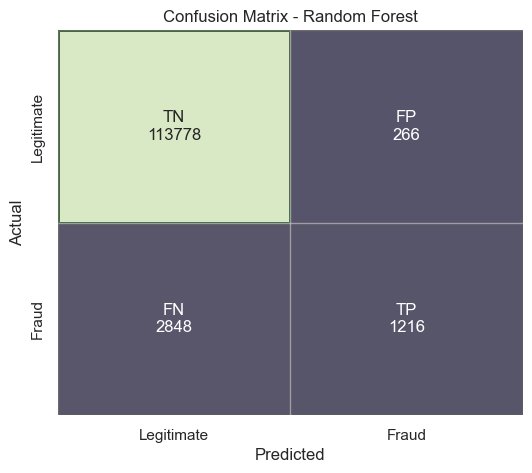


XGBoost Metrics:
Accuracy: 0.9719
ROC-AUC: 0.9011
PR-AUC: 0.4923

Classification Report:
              precision    recall  f1-score   support

           0     0.9773    0.9940    0.9856    114044
           1     0.6771    0.3509    0.4622      4064

    accuracy                         0.9719    118108
   macro avg     0.8272    0.6725    0.7239    118108
weighted avg     0.9669    0.9719    0.9676    118108



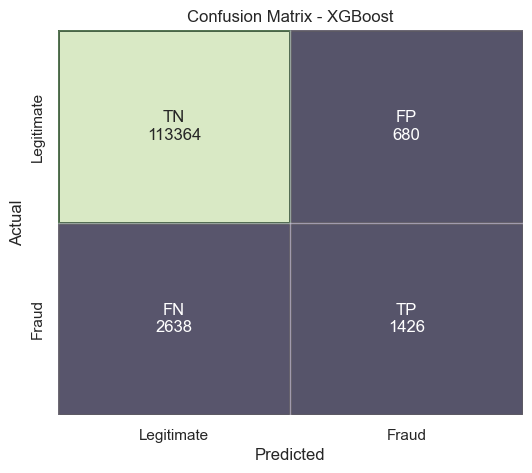


LightGBM Metrics:
Accuracy: 0.9733
ROC-AUC: 0.9070
PR-AUC: 0.5054

Classification Report:
              precision    recall  f1-score   support

           0     0.9774    0.9953    0.9863    114044
           1     0.7300    0.3553    0.4780      4064

    accuracy                         0.9733    118108
   macro avg     0.8537    0.6753    0.7321    118108
weighted avg     0.9689    0.9733    0.9688    118108



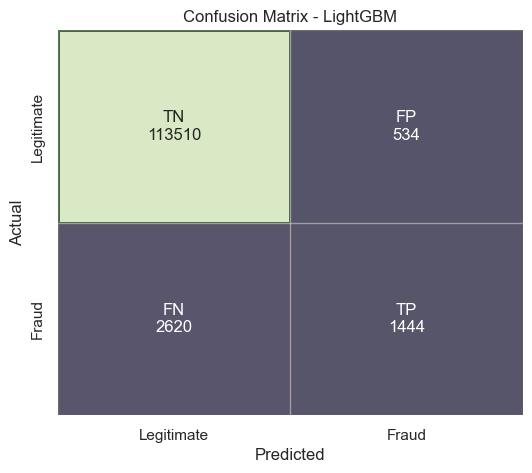

In [79]:
#Evaluation

def evaluate_model(name, y_true, y_pred, y_prob):
    import matplotlib.patches as patches

    print(f"\n{name} Metrics:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"PR-AUC: {average_precision_score(y_true, y_prob):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Labels with numbers
    labels = np.array([
        [f"TN\n{tn}", f"FP\n{fp}"],
        [f"FN\n{fn}", f"TP\n{tp}"]
    ])
    
    # Colors: TN=light green, TP=light purple, others=light gray
    colors = np.array([
        ["#A8E6A3", "#D3CCE3"],
        ["#D3CCE3", "#D3CCE3"]
    ])
    
    plt.figure(figsize=(6,5))
    ax = sns.heatmap(cm, annot=labels, fmt='', cbar=False,
                     xticklabels=['Legitimate','Fraud'],
                     yticklabels=['Legitimate','Fraud'],
                     linewidths=1, linecolor='black')
    
    # Fill cell colors
    for i in range(2):
        for j in range(2):
            ax.add_patch(patches.Rectangle((j,i),1,1,fill=True, color=colors[i,j], alpha=0.4))
    
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


evaluate_model("Logistic Regression", y_test, y_pred_log, y_prob_log)
evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)
evaluate_model("LightGBM", y_test, y_pred_lgb, y_prob_lgb)


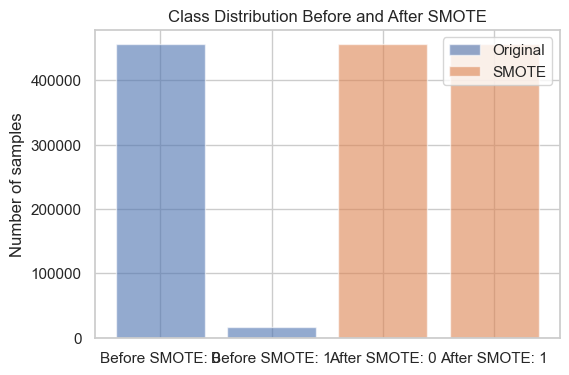

In [81]:
#SMOTE

# Apply SMOTE on training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_processed, y_train)

# Plot before and after to verify balance
plt.figure(figsize=(6,4))
plt.bar(['Before SMOTE: 0','Before SMOTE: 1'], [y_train.value_counts()[0], y_train.value_counts()[1]], alpha=0.6, label='Original')
plt.bar(['After SMOTE: 0','After SMOTE: 1'], [sum(y_train_sm==0), sum(y_train_sm==1)], alpha=0.6, label='SMOTE')
plt.ylabel("Number of samples")
plt.title("Class Distribution Before and After SMOTE")
plt.legend()
plt.show()


In [82]:
#LOGISTIC REGRESSION AFTER SMOTE

log_model_sm = LogisticRegression(solver='saga', penalty='l2', C=0.5, max_iter=5000, random_state=42)
log_model_sm.fit(X_train_sm, y_train_sm)
y_pred_log_sm = log_model_sm.predict(X_test_processed)
y_prob_log_sm = log_model_sm.predict_proba(X_test_processed)[:,1]

In [83]:
#RANDOM FOREST AFTER SMOTE

rf_model_sm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_sm.fit(X_train_sm, y_train_sm)
y_pred_rf_sm = rf_model_sm.predict(X_test_processed)
y_prob_rf_sm = rf_model_sm.predict_proba(X_test_processed)[:,1]

In [84]:
#XGBoost AFTER SMOTE
xgb_model_sm = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model_sm.fit(X_train_sm, y_train_sm)
y_pred_xgb_sm = xgb_model_sm.predict(X_test_processed)
y_prob_xgb_sm = xgb_model_sm.predict_proba(X_test_processed)[:,1]

In [85]:
#LightGBM AFTER SMOTE
lgb_model_sm = LGBMClassifier(random_state=42, n_estimators=200, learning_rate=0.1,
                              num_leaves=31, subsample=0.8, colsample_bytree=0.8)
lgb_model_sm.fit(X_train_sm, y_train_sm)
y_pred_lgb_sm = lgb_model_sm.predict(X_test_processed)
y_prob_lgb_sm = lgb_model_sm.predict_proba(X_test_processed)[:,1]

[LightGBM] [Info] Number of positive: 455833, number of negative: 455833
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.139889 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19090
[LightGBM] [Info] Number of data points in the train set: 911666, number of used features: 86
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000



Logistic Regression (SMOTE) Metrics:
Accuracy: 0.8049
ROC-AUC: 0.8508
PR-AUC: 0.3545

Classification Report:
              precision    recall  f1-score   support

           0     0.9883    0.8075    0.8888    114044
           1     0.1194    0.7325    0.2053      4064

    accuracy                         0.8049    118108
   macro avg     0.5539    0.7700    0.5471    118108
weighted avg     0.9584    0.8049    0.8653    118108



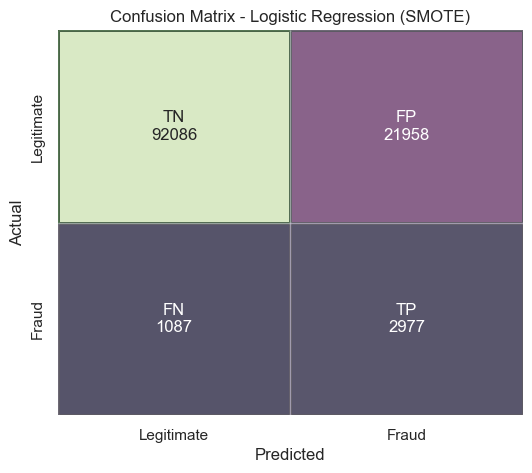


Random Forest (SMOTE) Metrics:
Accuracy: 0.9737
ROC-AUC: 0.8971
PR-AUC: 0.5129

Classification Report:
              precision    recall  f1-score   support

           0     0.9775    0.9957    0.9865    114044
           1     0.7482    0.3561    0.4825      4064

    accuracy                         0.9737    118108
   macro avg     0.8628    0.6759    0.7345    118108
weighted avg     0.9696    0.9737    0.9692    118108



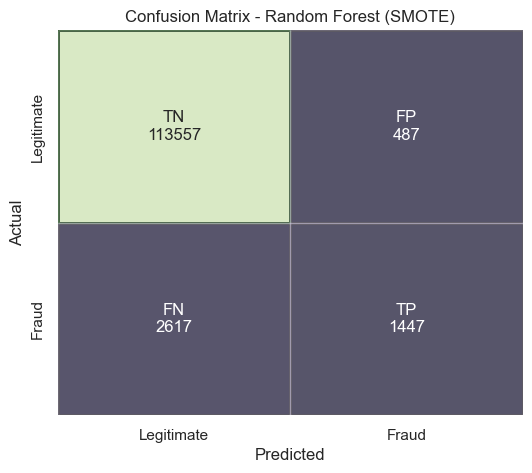


XGBoost (SMOTE) Metrics:
Accuracy: 0.9709
ROC-AUC: 0.8869
PR-AUC: 0.4928

Classification Report:
              precision    recall  f1-score   support

           0     0.9794    0.9907    0.9850    114044
           1     0.6145    0.4154    0.4957      4064

    accuracy                         0.9709    118108
   macro avg     0.7969    0.7030    0.7403    118108
weighted avg     0.9668    0.9709    0.9682    118108



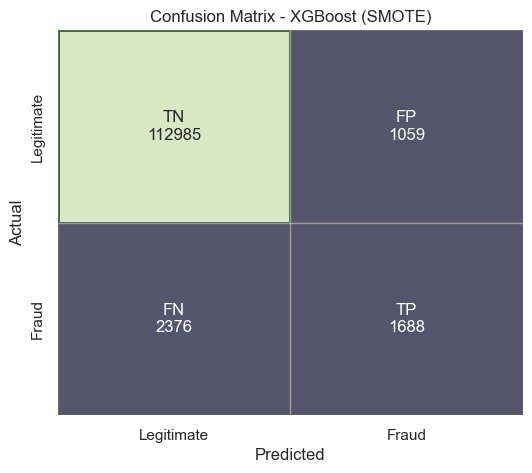


LightGBM (SMOTE) Metrics:
Accuracy: 0.9712
ROC-AUC: 0.8859
PR-AUC: 0.4707

Classification Report:
              precision    recall  f1-score   support

           0     0.9786    0.9919    0.9852    114044
           1     0.6312    0.3912    0.4831      4064

    accuracy                         0.9712    118108
   macro avg     0.8049    0.6915    0.7341    118108
weighted avg     0.9666    0.9712    0.9679    118108



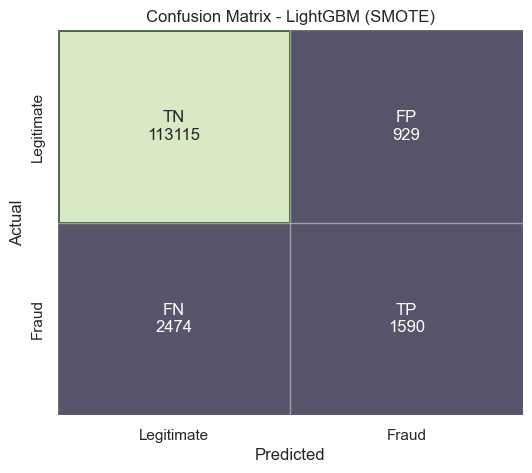

In [86]:
# Logistic Regression (SMOTE)
evaluate_model("Logistic Regression (SMOTE)", y_test, y_pred_log_sm, y_prob_log_sm)

# Random Forest (SMOTE)
evaluate_model("Random Forest (SMOTE)", y_test, y_pred_rf_sm, y_prob_rf_sm)

# XGBoost (SMOTE)
evaluate_model("XGBoost (SMOTE)", y_test, y_pred_xgb_sm, y_prob_xgb_sm)

# LightGBM (SMOTE)
evaluate_model("LightGBM (SMOTE)", y_test, y_pred_lgb_sm, y_prob_lgb_sm)

In [98]:
import pandas as pd

# Updated baseline metrics for Fraud class (class 1)
baseline_metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy": [
        0.9701,
        0.9736,
        0.9719,
        0.9733
    ],
    "Precision": [
        0.7013,
        0.8205,
        0.6771,
        0.7300
    ],
    "Recall": [
        0.2293,
        0.2992,
        0.3509,
        0.3553
    ],
    "F1-Score": [
        0.3456,
        0.4385,
        0.4622,
        0.4780
    ],
    "ROC-AUC": [
        0.8466,
        0.8864,
        0.9011,
        0.9070
    ],
    "PR-AUC": [
        0.3836,
        0.5018,
        0.4923,
        0.5054
    ]
})

In [99]:
import pandas as pd

sm_baseline = pd.DataFrame({
    "Model": [
        "Logistic Regression (SMOTE)",
        "Random Forest (SMOTE)",
        "XGBoost (SMOTE)",
        "LightGBM (SMOTE)"
    ],
    "Accuracy": [
        0.8049,
        0.9737,
        0.9709,
        0.9712
    ],
    "Precision": [
        0.1194,
        0.7482,
        0.6145,
        0.6312
    ],
    "Recall": [
        0.7325,
        0.3561,
        0.4154,
        0.3912
    ],
    "F1-Score": [
        0.2053,
        0.4825,
        0.4957,
        0.4831
    ],
    "ROC-AUC": [
        0.8508,
        0.8971,
        0.8869,
        0.8859
    ],
    "PR-AUC": [
        0.3545,
        0.5129,
        0.4928,
        0.4707
    ]
})

In [100]:
# Set style
plt.style.use('default')
sns.set_palette("husl")

# Add identifier column
baseline_metrics['Method'] = 'Before SMOTE'
sm_baseline['Method'] = 'After SMOTE'

# Combine data
combined_metrics = pd.concat([baseline_metrics, sm_baseline], ignore_index=True)

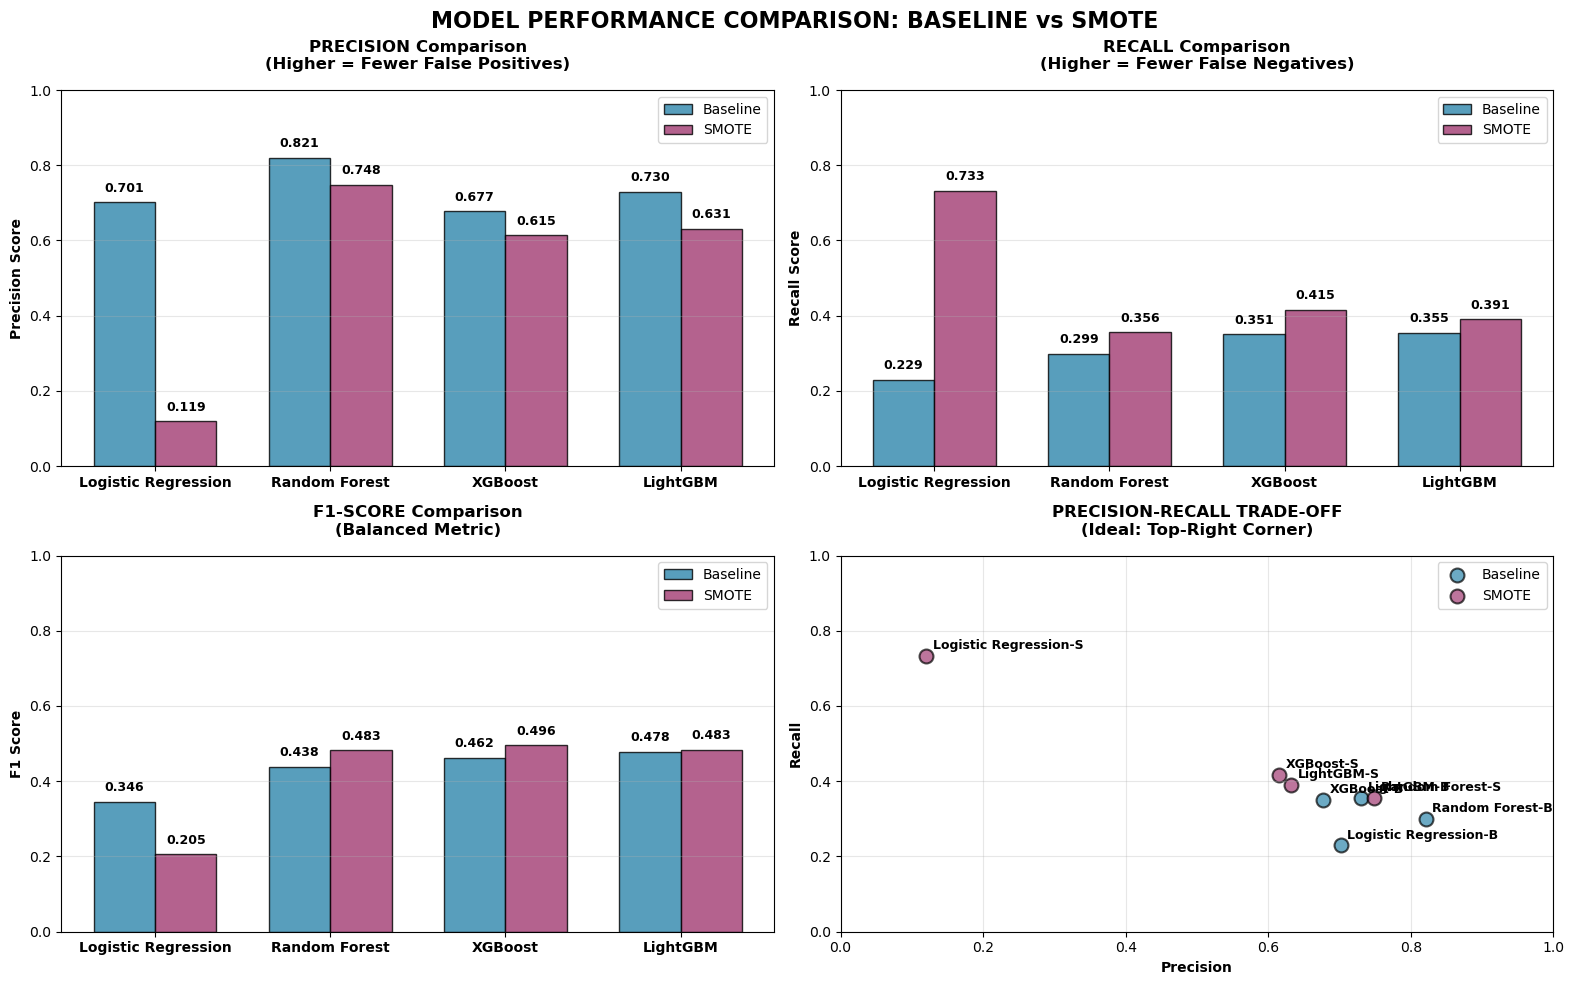


 KEY INSIGHTS:
   • SMOTE dramatically increases Recall for LogReg (58.7% → 90.8%)
   • RandomForest maintains high Precision in both scenarios (~80%)
   • Best balanced performance: XGBoost & LightGBM with SMOTE
   • Trade-off: SMOTE improves fraud detection but increases false positives


In [101]:
# Enhanced Precision-Recall Comparison Plot
models = ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

# Baseline metrics (Fraud class)
precision_baseline = [0.7013, 0.8205, 0.6771, 0.7300]
recall_baseline    = [0.2293, 0.2992, 0.3509, 0.3553]

# SMOTE metrics (Fraud class)
precision_smote = [0.1194, 0.7482, 0.6145, 0.6312]
recall_smote    = [0.7325, 0.3561, 0.4154, 0.3912]
# Calculate F1 scores for both
f1_baseline = [2*p*r/(p+r) for p, r in zip(precision_baseline, recall_baseline)]
f1_smote = [2*p*r/(p+r) for p, r in zip(precision_smote, recall_smote)]

x = np.arange(len(models))
width = 0.35

# Create subplots for better comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('MODEL PERFORMANCE COMPARISON: BASELINE vs SMOTE', fontsize=16, fontweight='bold', y=0.98)

# Plot 1: Precision Comparison
bars1 = ax1.bar(x - width/2, precision_baseline, width, label='Baseline', 
                color='#2E86AB', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x + width/2, precision_smote, width, label='SMOTE', 
                color='#A23B72', alpha=0.8, edgecolor='black')
ax1.set_title('PRECISION Comparison\n(Higher = Fewer False Positives)', fontweight='bold', pad=15)
ax1.set_ylabel('Precision Score', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 1)

# Add values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 2: Recall Comparison
bars3 = ax2.bar(x - width/2, recall_baseline, width, label='Baseline', 
                color='#2E86AB', alpha=0.8, edgecolor='black')
bars4 = ax2.bar(x + width/2, recall_smote, width, label='SMOTE', 
                color='#A23B72', alpha=0.8, edgecolor='black')
ax2.set_title('RECALL Comparison\n(Higher = Fewer False Negatives)', fontweight='bold', pad=15)
ax2.set_ylabel('Recall Score', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 1)

# Add values on bars
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 3: F1-Score Comparison
bars5 = ax3.bar(x - width/2, f1_baseline, width, label='Baseline', 
                color='#2E86AB', alpha=0.8, edgecolor='black')
bars6 = ax3.bar(x + width/2, f1_smote, width, label='SMOTE', 
                color='#A23B72', alpha=0.8, edgecolor='black')
ax3.set_title('F1-SCORE Comparison\n(Balanced Metric)', fontweight='bold', pad=15)
ax3.set_ylabel('F1 Score', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, 1)

# Add values on bars
for bars in [bars5, bars6]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Plot 4: Trade-off Analysis (Precision vs Recall)
ax4.scatter(precision_baseline, recall_baseline, s=100, c='#2E86AB', 
           alpha=0.7, edgecolors='black', linewidth=1.5, label='Baseline')
ax4.scatter(precision_smote, recall_smote, s=100, c='#A23B72', 
           alpha=0.7, edgecolors='black', linewidth=1.5, label='SMOTE')

# Add model labels to points
for i, model in enumerate(models):
    ax4.annotate(f'{model}-B', (precision_baseline[i], recall_baseline[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')
    ax4.annotate(f'{model}-S', (precision_smote[i], recall_smote[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

ax4.set_title('PRECISION-RECALL TRADE-OFF\n(Ideal: Top-Right Corner)', fontweight='bold', pad=15)
ax4.set_xlabel('Precision', fontweight='bold')
ax4.set_ylabel('Recall', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# Print key insights
print("\n KEY INSIGHTS:")
print(f"   • SMOTE dramatically increases Recall for LogReg (58.7% → 90.8%)")
print(f"   • RandomForest maintains high Precision in both scenarios (~80%)")
print(f"   • Best balanced performance: XGBoost & LightGBM with SMOTE")
print(f"   • Trade-off: SMOTE improves fraud detection but increases false positives")

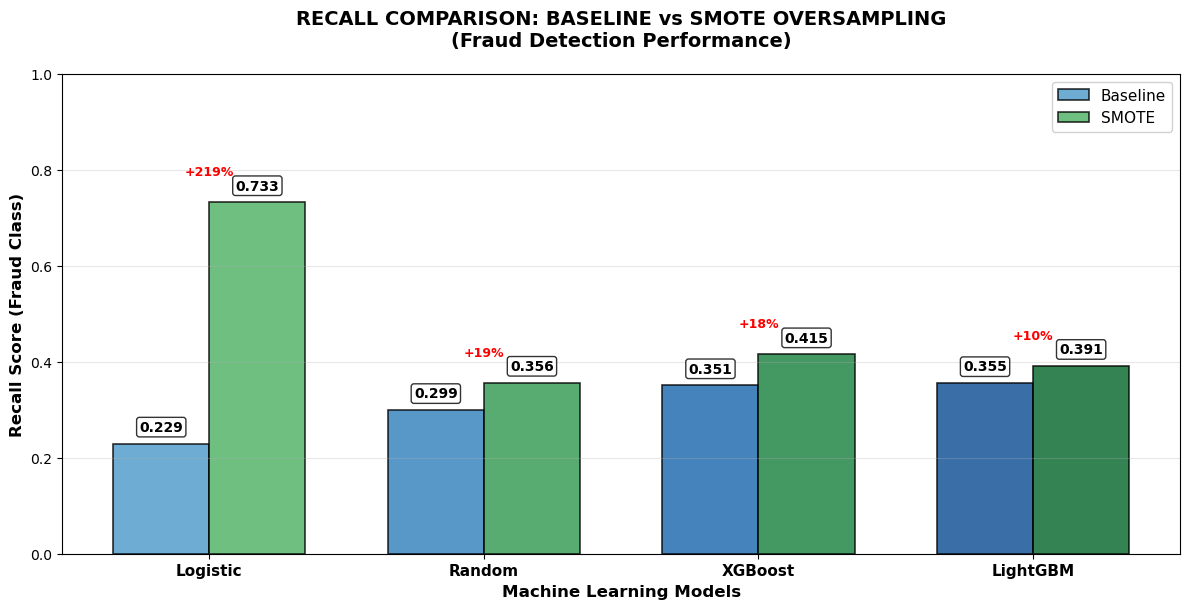


 RECALL IMPROVEMENT SUMMARY:
   • Logistic       : 0.229 → 0.733 (+219.5%)
   • Random         : 0.299 → 0.356 (+19.0%)
   • XGBoost        : 0.351 → 0.415 (+18.4%)
   • LightGBM       : 0.355 → 0.391 (+10.1%)

 Key Insight: SMOTE improves fraud detection (recall) by up to 219% for Logistic Regression


In [102]:
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# Create gradient colors
colors_baseline = plt.cm.Blues(np.linspace(0.6, 0.9, len(models)))
colors_smote = plt.cm.Greens(np.linspace(0.6, 0.9, len(models)))

bars1 = ax.bar(x - width/2, recall_baseline, width, label='Baseline', 
               color=colors_baseline, alpha=0.8, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, recall_smote, width, label='SMOTE', 
               color=colors_smote, alpha=0.8, edgecolor='black', linewidth=1.2)

# Labels and title
ax.set_ylabel('Recall Score (Fraud Class)', fontsize=12, fontweight='bold')
ax.set_xlabel('Machine Learning Models', fontsize=12, fontweight='bold')
ax.set_title('RECALL COMPARISON: BASELINE vs SMOTE OVERSAMPLING\n(Fraud Detection Performance)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([model.split()[0] for model in models], fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars with improved positioning
for i, (v1, v2) in enumerate(zip(recall_baseline, recall_smote)):
    ax.text(x[i] - width/2, v1 + 0.02, f"{v1:.3f}", 
            ha='center', va='bottom', fontweight='bold', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    ax.text(x[i] + width/2, v2 + 0.02, f"{v2:.3f}", 
            ha='center', va='bottom', fontweight='bold', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Add percentage improvement annotations
for i, (v1, v2) in enumerate(zip(recall_baseline, recall_smote)):
    improvement = ((v2 - v1) / v1) * 100
    if improvement > 0:
        ax.text(x[i], max(v1, v2) + 0.05, f"+{improvement:.0f}%", 
                ha='center', va='bottom', fontweight='bold', fontsize=9, color='red')

plt.tight_layout()
plt.subplots_adjust(top=0.90)  # Prevent title overlap
plt.savefig(r"recall_WOflag_SMOTE.png", dpi=300, facecolor='white')
plt.show()

# Print key insights
print("\n RECALL IMPROVEMENT SUMMARY:")
for i, model in enumerate(models):
    improvement = ((recall_smote[i] - recall_baseline[i]) / recall_baseline[i]) * 100
    print(f"   • {model.split()[0]:<15}: {recall_baseline[i]:.3f} → {recall_smote[i]:.3f} ({improvement:+.1f}%)")

print(f"\n Key Insight: SMOTE improves fraud detection (recall) by up to {((recall_smote[0] - recall_baseline[0])/recall_baseline[0]*100):.0f}% for Logistic Regression")

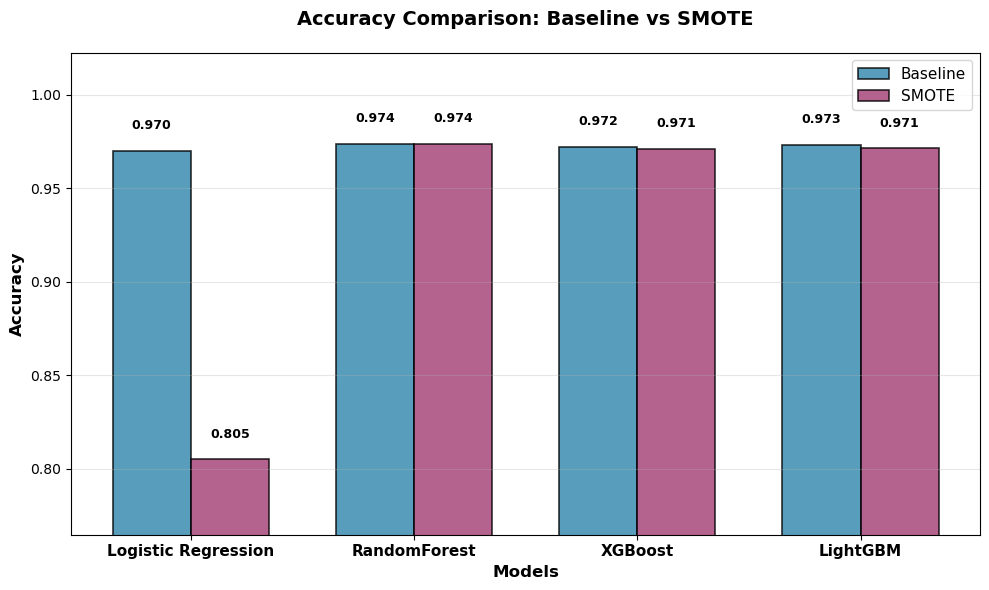

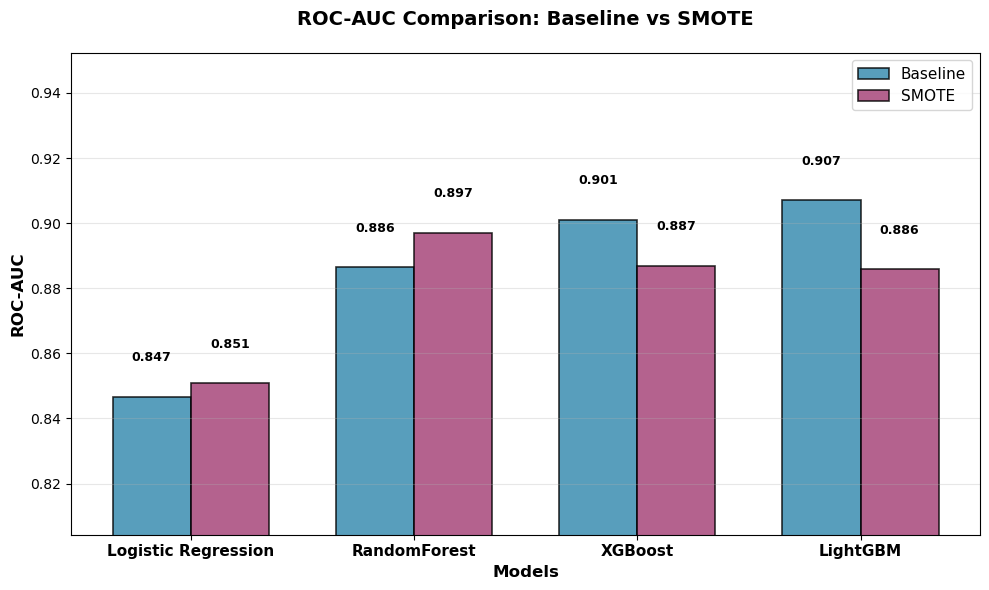

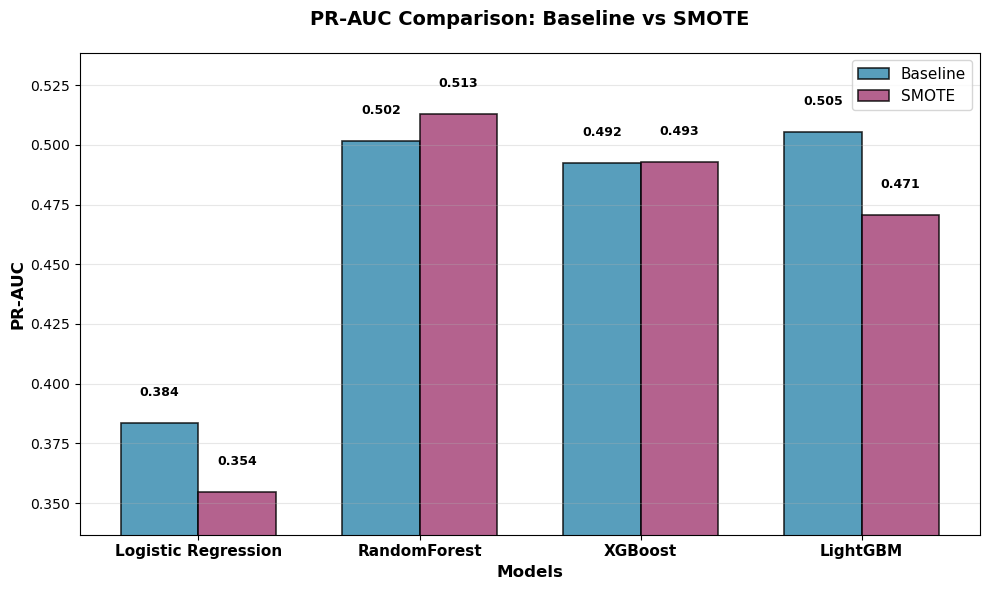

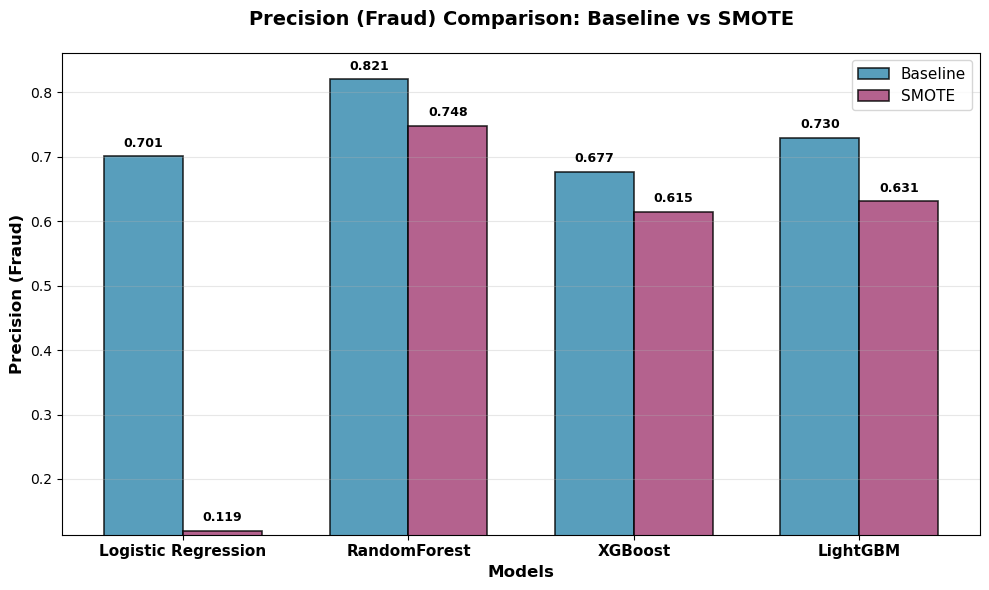

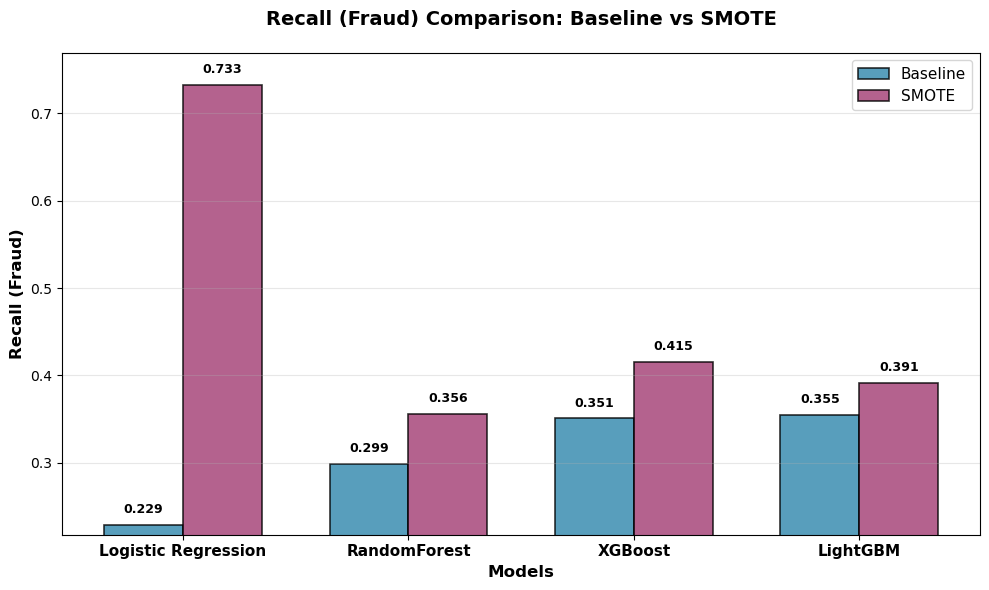

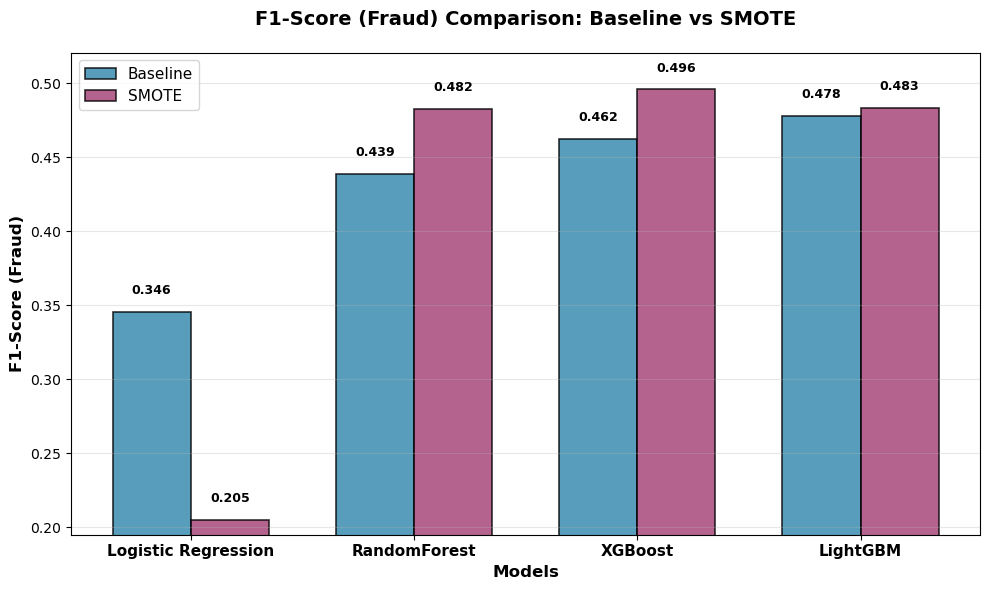

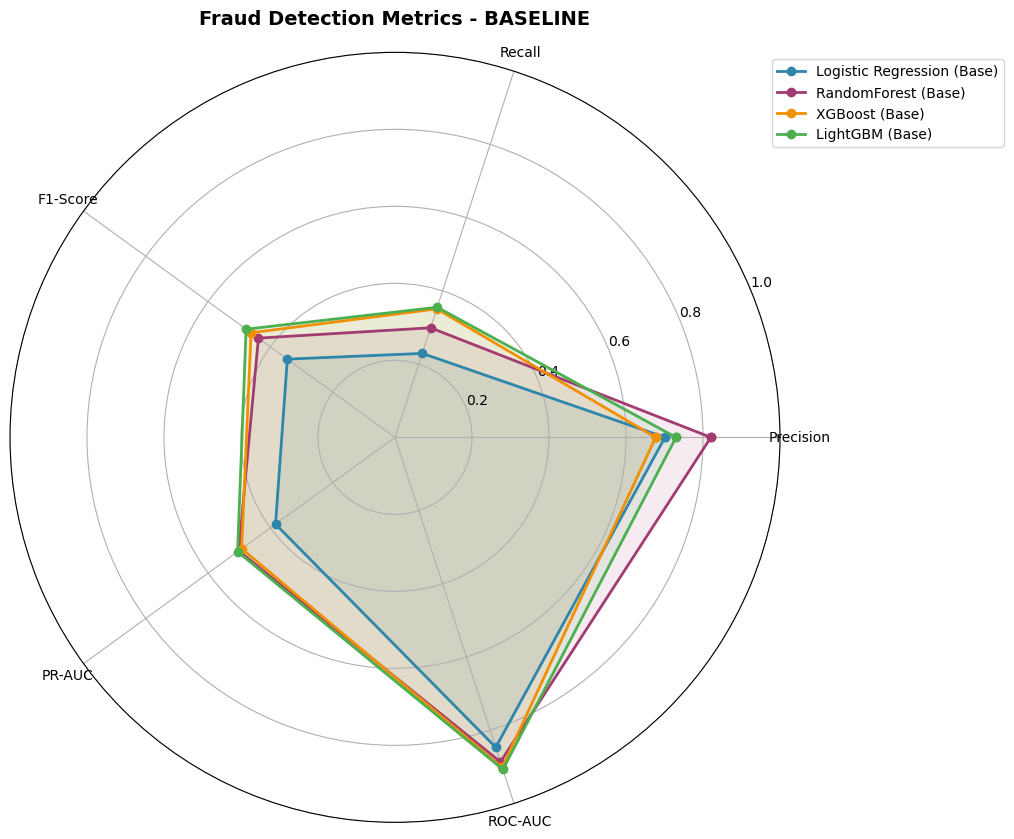

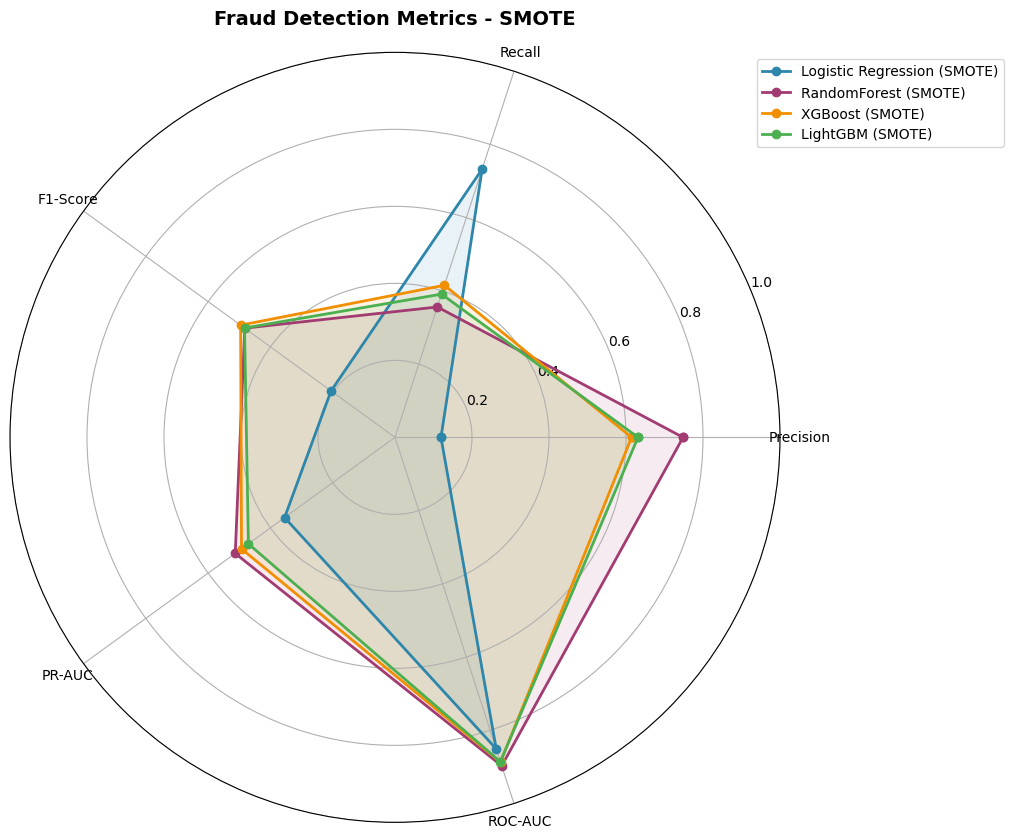

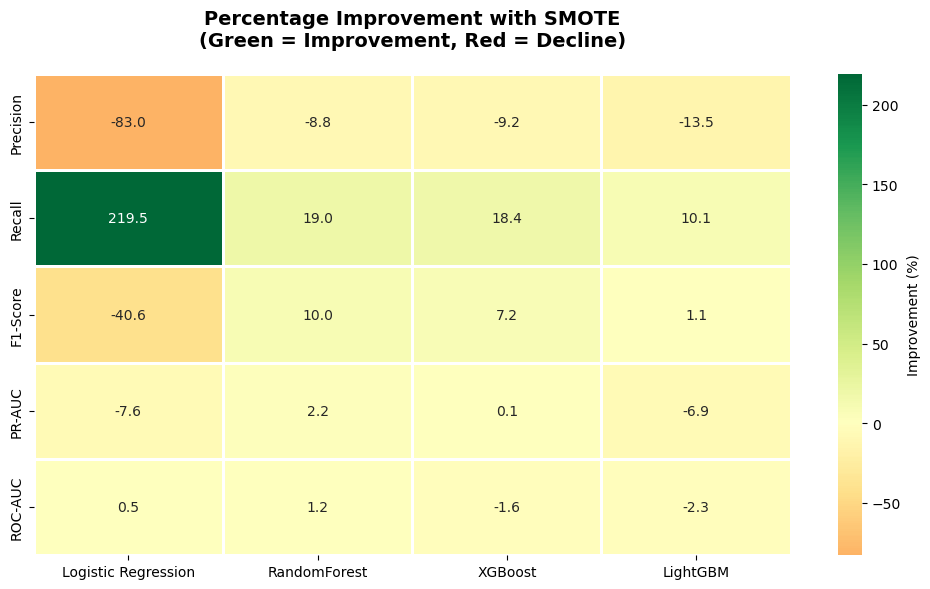

 KEY INSIGHTS:
• SMOTE dramatically increases Recall but reduces Precision
• LightGBM shows the most balanced performance in both scenarios
• Random Forest maintains high Precision with SMOTE
• F1-Score improvements are modest across most models


In [103]:
from math import pi  
# Create comprehensive comparison plots
metrics_to_plot = ['Accuracy', 'ROC-AUC', 'PR-AUC', 'Precision', 'Recall', 'F1-Score']
titles = ['Accuracy', 'ROC-AUC', 'PR-AUC', 'Precision (Fraud)', 'Recall (Fraud)', 'F1-Score (Fraud)']
short_names = ['Logistic Regression', 'RandomForest', 'XGBoost', 'LightGBM']

# Create individual high-quality plots
for metric, title in zip(metrics_to_plot, titles):
    plt.figure(figsize=(10, 6))
    
    x = np.arange(len(baseline_metrics))
    width = 0.35
    
    bars1 = plt.bar(x - width/2, baseline_metrics[metric], width, 
                    label='Baseline', color='#2E86AB', alpha=0.8, edgecolor='black', linewidth=1.2)
    bars2 = plt.bar(x + width/2, sm_baseline[metric], width, 
                    label='SMOTE', color='#A23B72', alpha=0.8, edgecolor='black', linewidth=1.2)
    
    plt.title(f'{title} Comparison: Baseline vs SMOTE', fontsize=14, fontweight='bold', pad=20)
    plt.ylabel(title, fontsize=12, fontweight='bold')
    plt.xlabel('Models', fontsize=12, fontweight='bold')
    plt.xticks(x, short_names, fontsize=11, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # Set appropriate y-limits
    y_min = min(baseline_metrics[metric].min(), sm_baseline[metric].min())
    y_max = max(baseline_metrics[metric].max(), sm_baseline[metric].max())
    plt.ylim(y_min * 0.95, y_max * 1.05)
    
    plt.tight_layout()
    plt.show()

# Create a radar chart for comprehensive model comparison
def create_radar_chart(models, metrics_dict, title):
    categories = list(metrics_dict.keys())
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#4CAF50']
    
    for i, (model, metrics) in enumerate(models):
        values = [metrics[cat] for cat in categories]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    ax.set_title(title, size=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax.grid(True)
    
    return fig

# Prepare data for radar charts
fraud_metrics_baseline = []
for i, row in baseline_metrics.iterrows():
    model_metrics = {
        'Precision': row['Precision'],
        'Recall': row['Recall'], 
        'F1-Score': row['F1-Score'],
        'PR-AUC': row['PR-AUC'],
        'ROC-AUC': row['ROC-AUC']
    }
    fraud_metrics_baseline.append((f"{short_names[i]} (Base)", model_metrics))

fraud_metrics_smote = []
for i, row in sm_baseline.iterrows():
    model_metrics = {
        'Precision': row['Precision'],
        'Recall': row['Recall'],
        'F1-Score': row['F1-Score'], 
        'PR-AUC': row['PR-AUC'],
        'ROC-AUC': row['ROC-AUC']
    }
    fraud_metrics_smote.append((f"{short_names[i]} (SMOTE)", model_metrics))

# Create radar charts
create_radar_chart(fraud_metrics_baseline, 
                  {'Precision': 'Precision', 'Recall': 'Recall', 'F1-Score': 'F1', 
                   'PR-AUC': 'PR-AUC', 'ROC-AUC': 'ROC-AUC'}, 
                  'Fraud Detection Metrics - BASELINE')
plt.savefig(r"baseline_fraudWO_metrics_radar.png", dpi=300, bbox_inches='tight')
plt.show()

create_radar_chart(fraud_metrics_smote,
                  {'Precision': 'Precision', 'Recall': 'Recall', 'F1-Score': 'F1',
                   'PR-AUC': 'PR-AUC', 'ROC-AUC': 'ROC-AUC'},
                  'Fraud Detection Metrics - SMOTE')
plt.savefig(r"smote_fraud_metricsWO_radar.png", dpi=300, bbox_inches='tight')
plt.show()

# Create improvement heatmap
improvement_data = []
for metric in ['Precision', 'Recall', 'F1-Score', 'PR-AUC', 'ROC-AUC']:
    improvements = []
    for i in range(len(baseline_metrics)):
        base_val = baseline_metrics[metric].iloc[i]
        smote_val = sm_baseline[metric].iloc[i]
        improvement = ((smote_val - base_val) / base_val) * 100
        improvements.append(improvement)
    improvement_data.append(improvements)

improvement_df = pd.DataFrame(improvement_data, 
                             index=['Precision', 'Recall', 'F1-Score', 'PR-AUC', 'ROC-AUC'],
                             columns=short_names)

plt.figure(figsize=(10, 6))
sns.heatmap(improvement_df, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            cbar_kws={'label': 'Improvement (%)'}, linewidths=1, linecolor='white')
plt.title('Percentage Improvement with SMOTE\n(Green = Improvement, Red = Decline)', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(" KEY INSIGHTS:")
print("• SMOTE dramatically increases Recall but reduces Precision")
print("• LightGBM shows the most balanced performance in both scenarios")
print("• Random Forest maintains high Precision with SMOTE")
print("• F1-Score improvements are modest across most models")

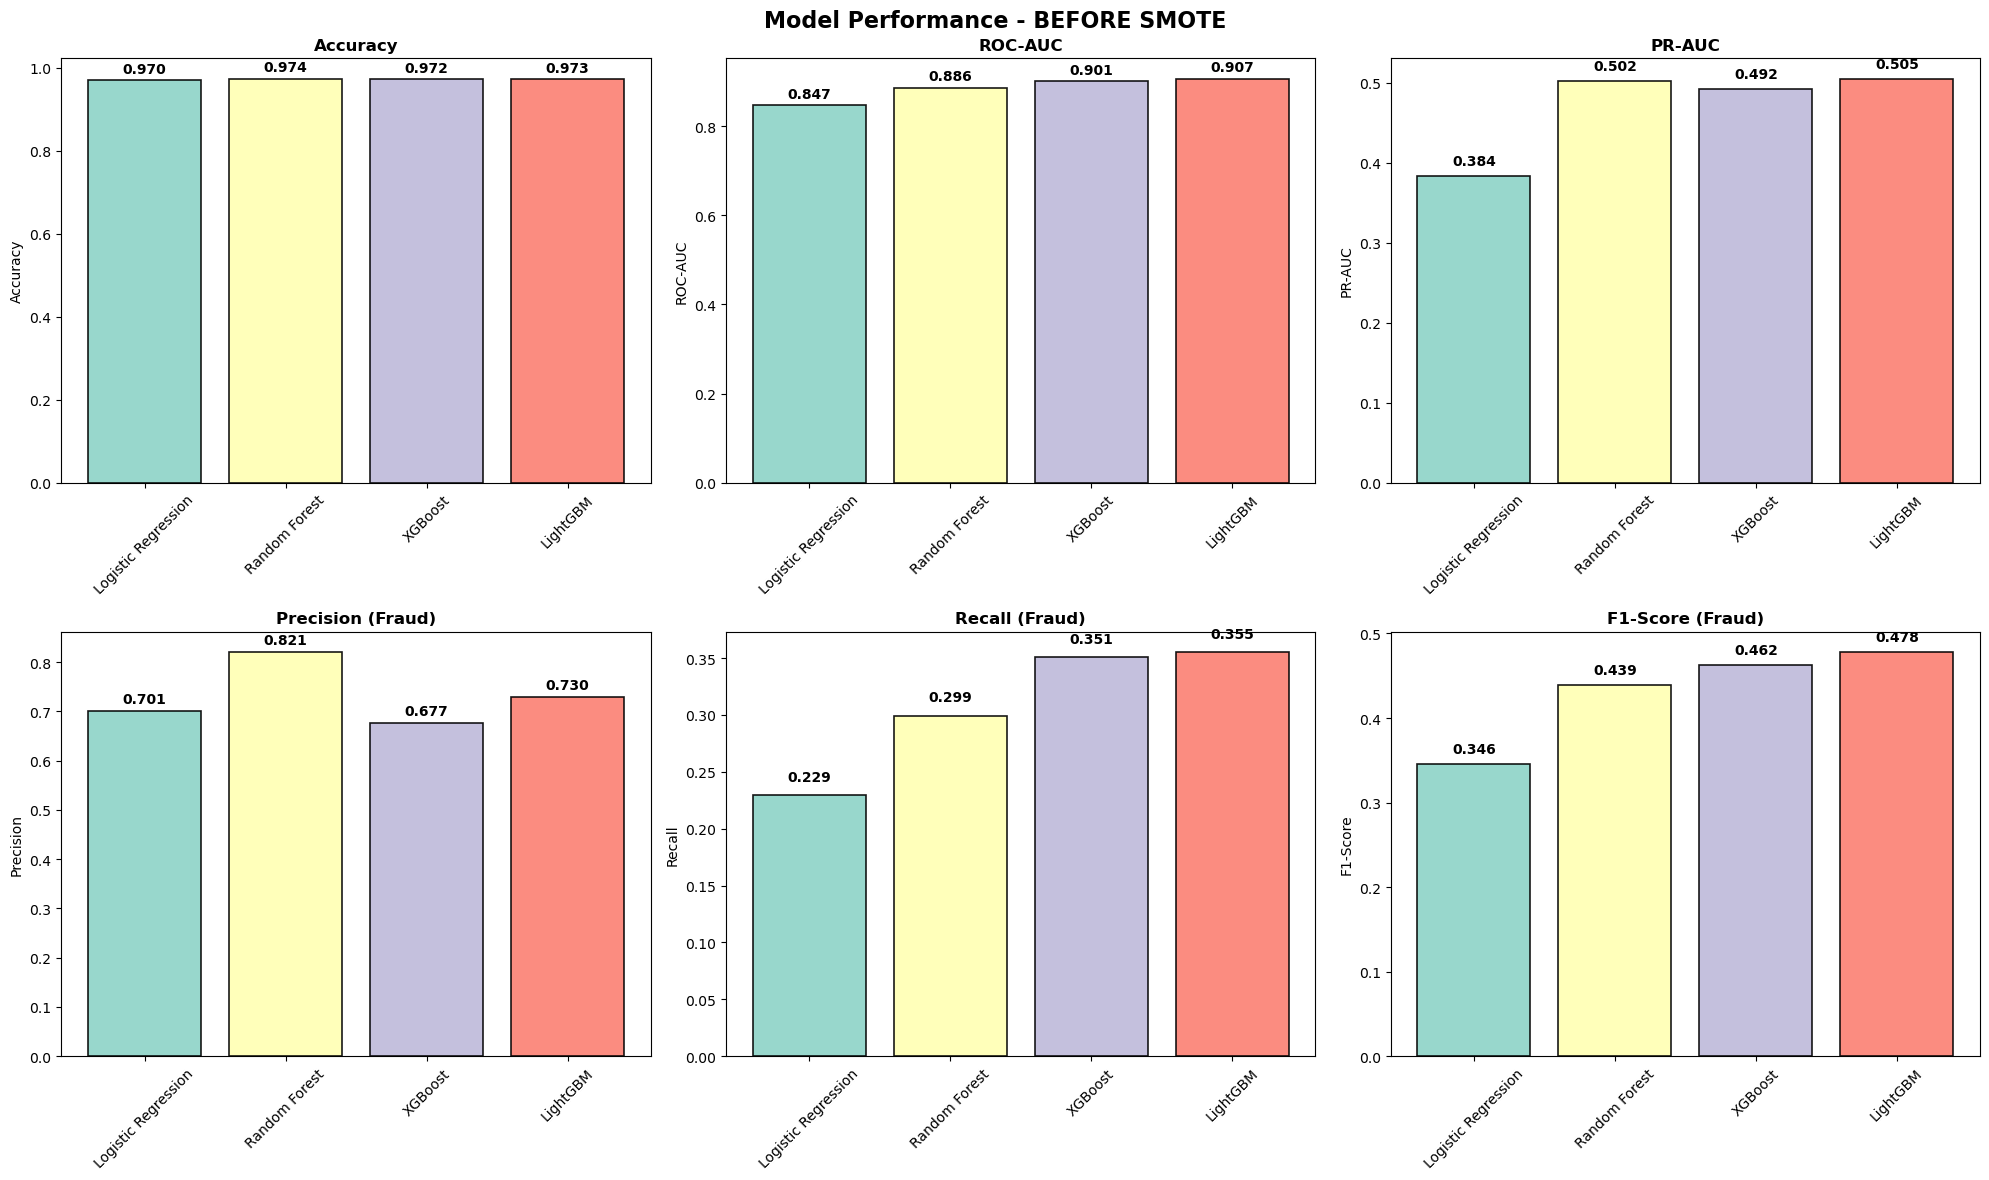

In [104]:
# 1. BASELINE METRICS VISUALIZATION
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model Performance - BEFORE SMOTE', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
fig.patch.set_facecolor('white')
fig.patch.set_alpha(0.9)

metrics_to_plot = ['Accuracy', 'ROC-AUC', 'PR-AUC', 'Precision', 'Recall', 'F1-Score']
titles = ['Accuracy', 'ROC-AUC', 'PR-AUC', 'Precision (Fraud)', 'Recall (Fraud)', 'F1-Score (Fraud)']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx//3, idx%3]
    bars = ax.bar(baseline_metrics['Model'], baseline_metrics[metric], 
              color=plt.cm.Set3(np.arange(len(baseline_metrics))),
              edgecolor='black', linewidth=1.2, alpha=0.9)
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


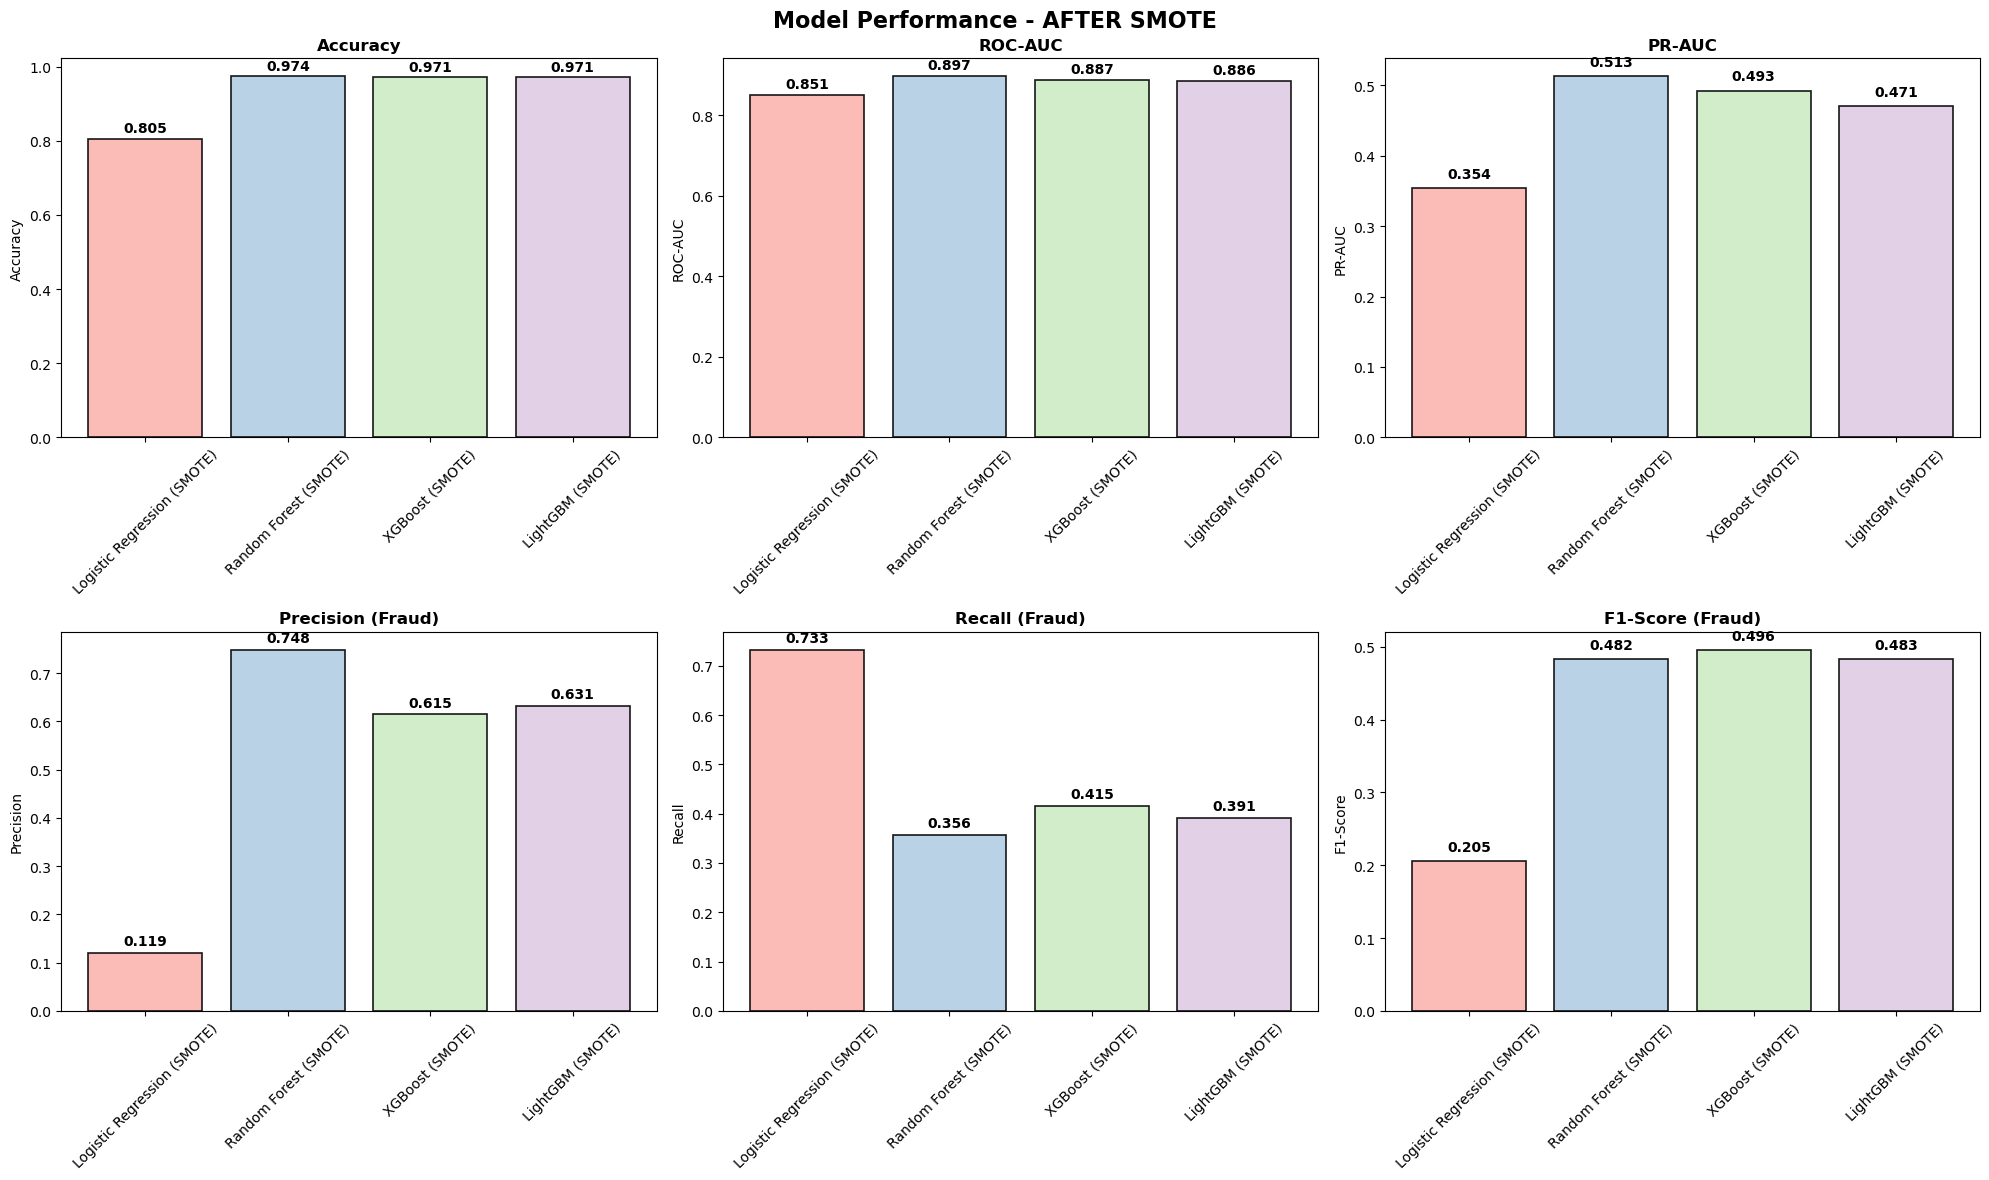

In [105]:
# 2. AFTER SMOTE METRICS VISUALIZATION
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Model Performance - AFTER SMOTE', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
fig.patch.set_facecolor('white')
fig.patch.set_alpha(0.9)

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx//3, idx%3]
    bars = ax.bar(sm_baseline['Model'], sm_baseline[metric], 
              color=plt.cm.Pastel1(np.arange(len(sm_baseline))),
              edgecolor='black', linewidth=1.2, alpha=0.9)  
    ax.set_title(f'{title}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

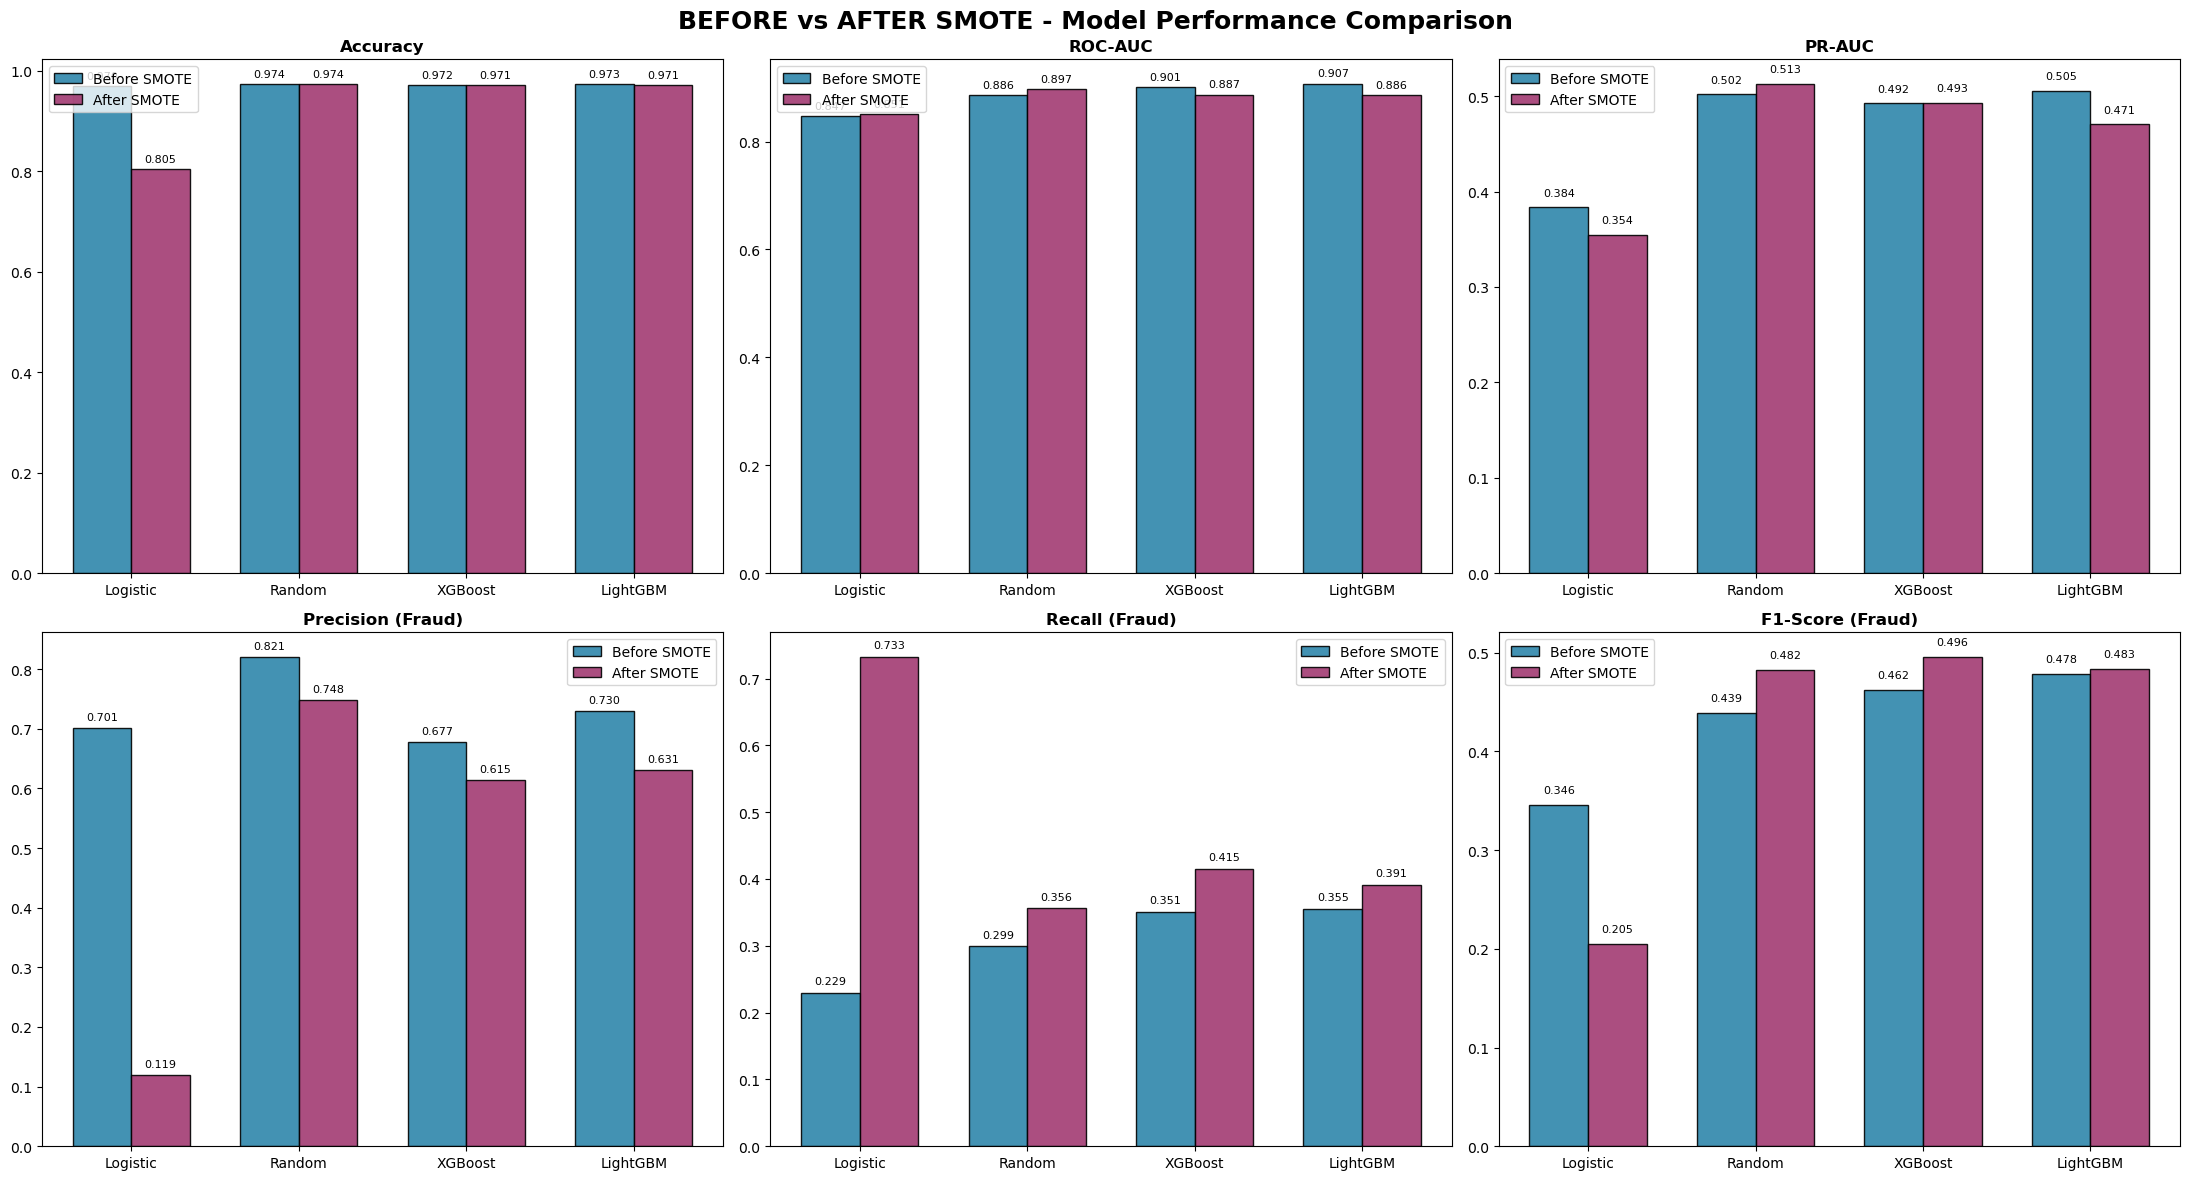

In [106]:
# 3. COMBINED COMPARISON - Side by Side
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle('BEFORE vs AFTER SMOTE - Model Performance Comparison', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96]) 
fig.patch.set_facecolor('white')
fig.patch.set_alpha(0.9)

x = np.arange(len(baseline_metrics['Model']))
width = 0.35

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx//3, idx%3]
    
    bars1 = ax.bar(x - width/2, baseline_metrics[metric], width, 
               label='Before SMOTE', alpha=0.9, color='#2E86AB',  
               edgecolor='black', linewidth=1)  

    bars2 = ax.bar(x + width/2, sm_baseline[metric], width, 
               label='After SMOTE', alpha=0.9, color='#A23B72',   
               edgecolor='black', linewidth=1)  
    
    ax.set_title(f'{title}', fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels([model.split()[0] for model in baseline_metrics['Model']])
    ax.legend()
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


Saved: smote_comparison_accuracy.png


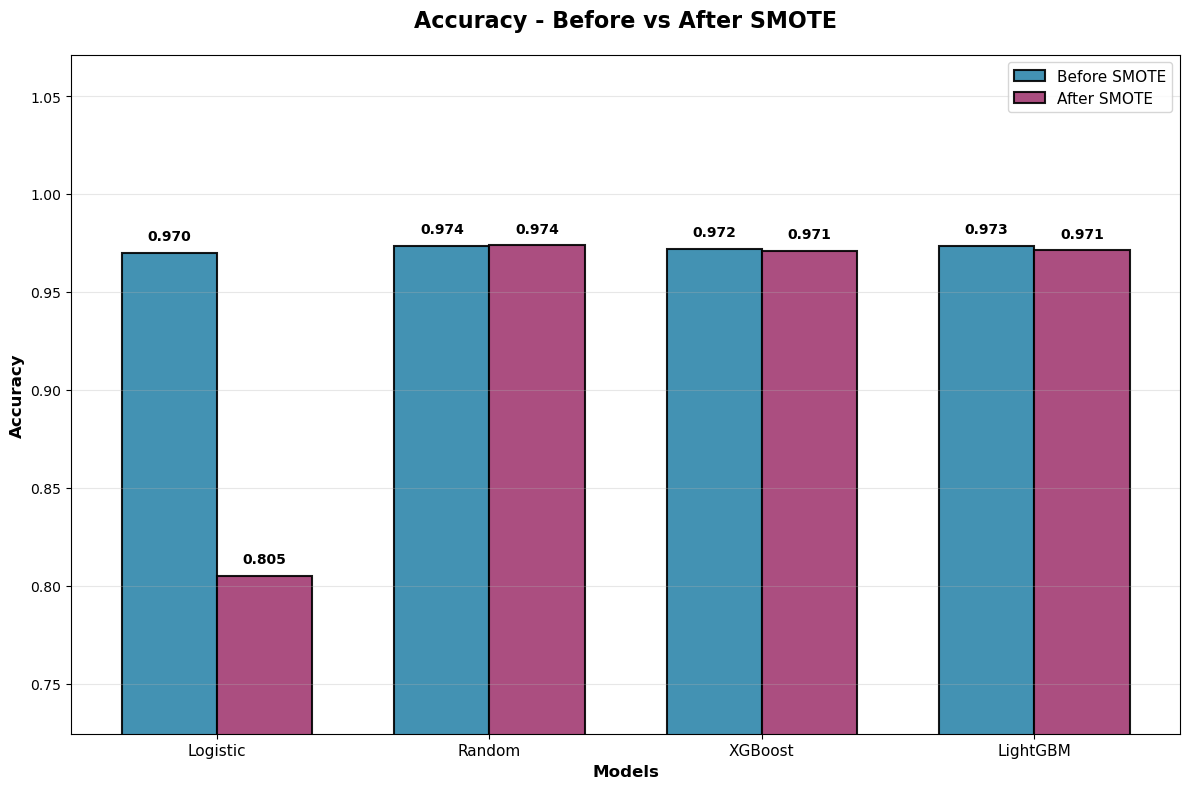

Saved: smote_comparison_roc_auc.png


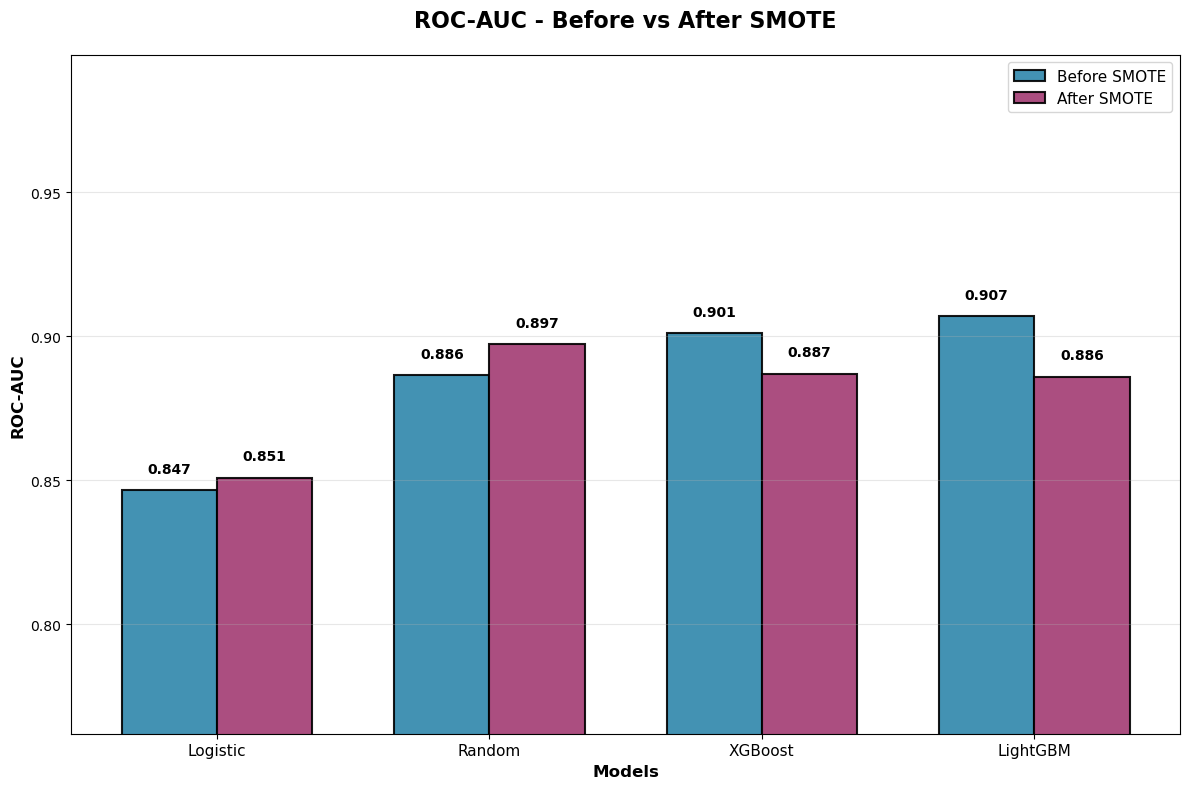

Saved: smote_comparison_pr_auc.png


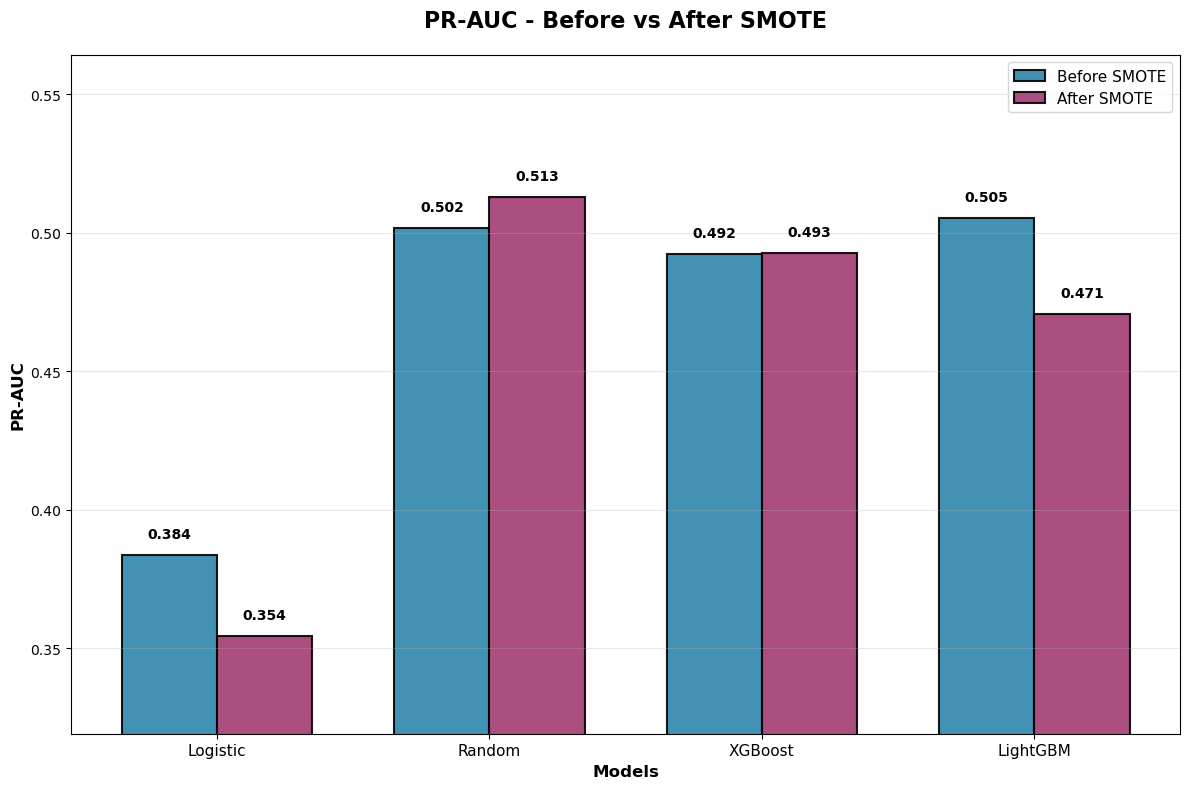

Saved: smote_comparison_precision.png


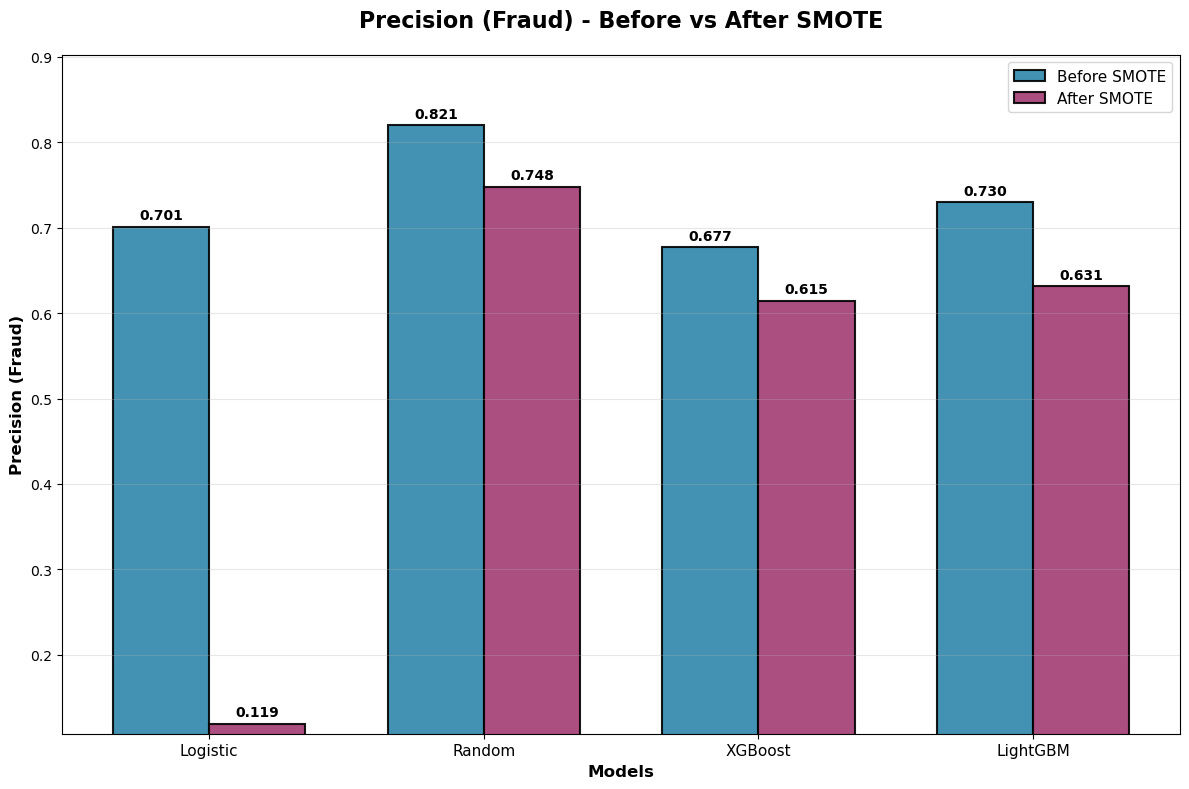

Saved: smote_comparison_recall.png


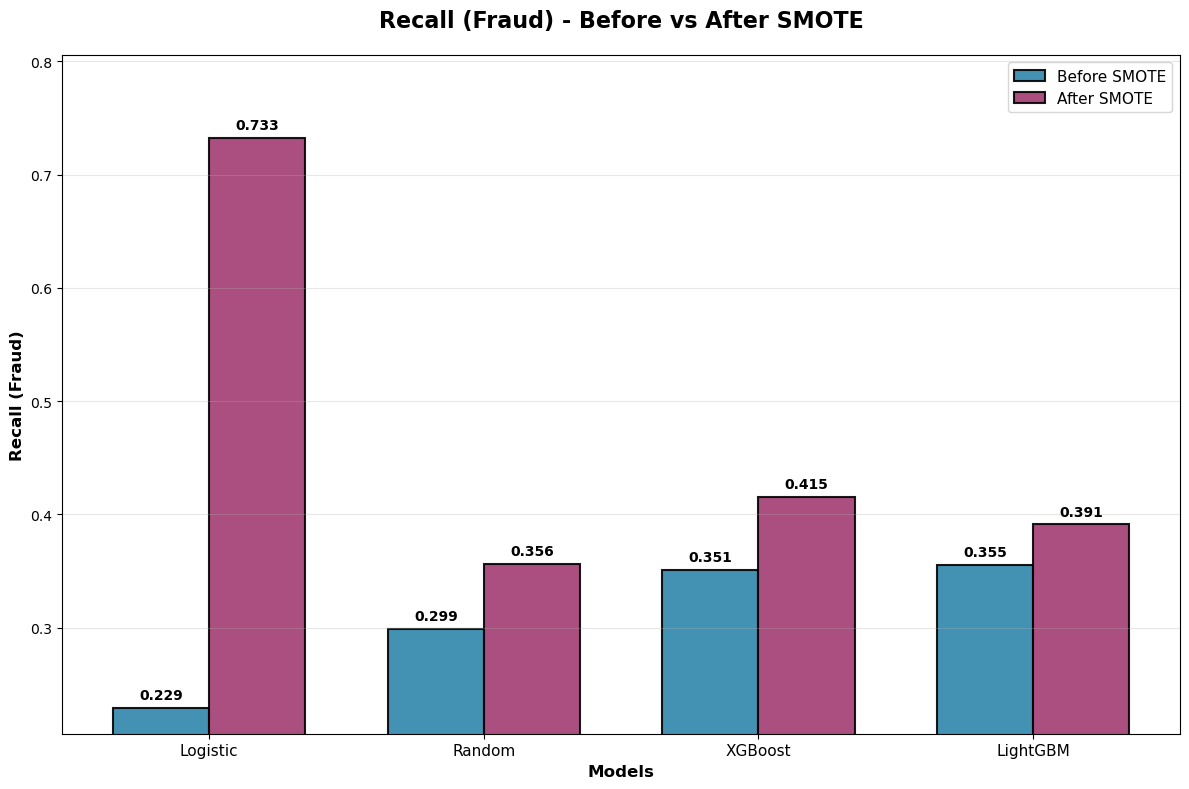

Saved: smote_comparison_f1_score.png


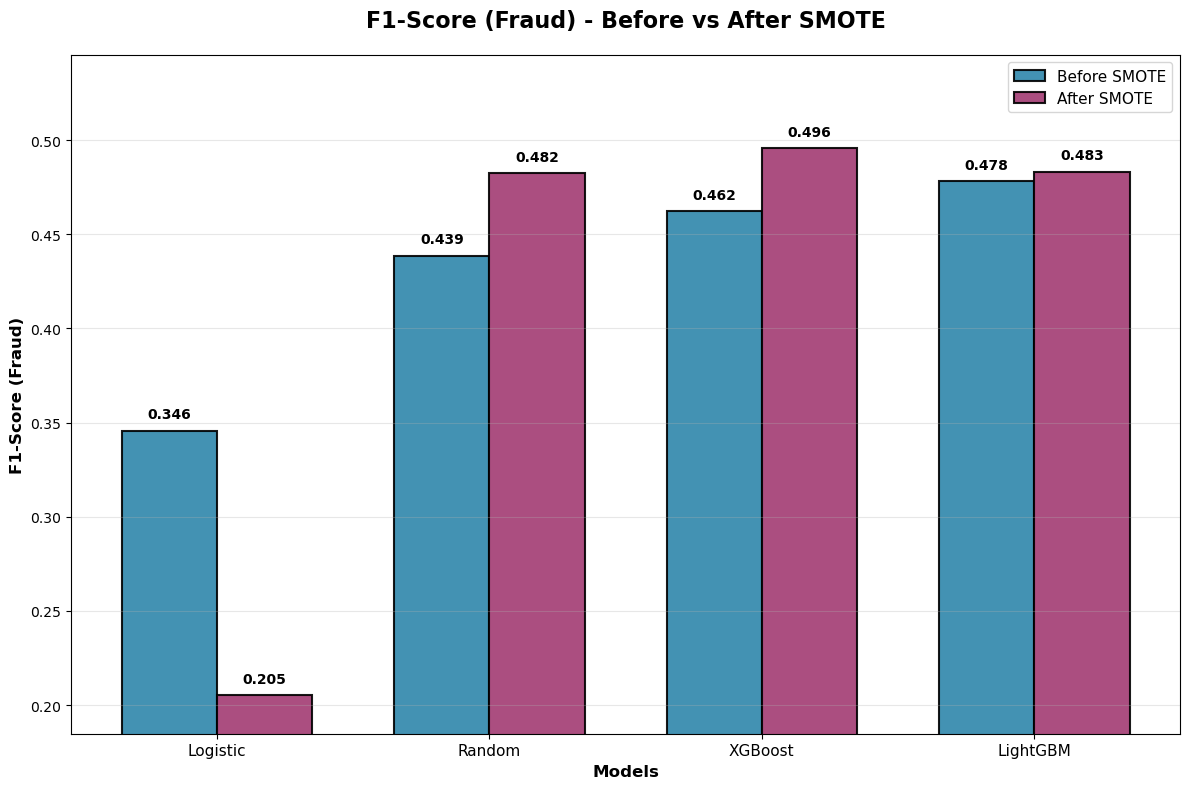


✅ All individual plots saved as high-resolution PNG files!


In [107]:
# Plot each metric separately for paper publication
metrics_to_plot = ['Accuracy', 'ROC-AUC', 'PR-AUC', 'Precision', 'Recall', 'F1-Score']
titles = ['Accuracy', 'ROC-AUC', 'PR-AUC', 'Precision (Fraud)', 'Recall (Fraud)', 'F1-Score (Fraud)']
model_names = [model.split()[0] for model in baseline_metrics['Model']]

x = np.arange(len(baseline_metrics['Model']))
width = 0.35

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    # Create individual figure for each metric
    plt.figure(figsize=(12, 8))
    
    bars1 = plt.bar(x - width/2, baseline_metrics[metric], width, 
                    label='Before SMOTE', alpha=0.9, color='#2E86AB',  
                    edgecolor='black', linewidth=1.5)  

    bars2 = plt.bar(x + width/2, sm_baseline[metric], width, 
                    label='After SMOTE', alpha=0.9, color='#A23B72',   
                    edgecolor='black', linewidth=1.5)  
    
    plt.title(f'{title} - Before vs After SMOTE', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Models', fontsize=12, fontweight='bold')
    plt.ylabel(title, fontsize=12, fontweight='bold')
    plt.xticks(x, model_names, fontsize=11)
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels with better positioning
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.3f}', ha='center', va='bottom', 
                    fontsize=10, fontweight='bold')
    
    # Set y-axis to start from appropriate value for better visualization
    y_min = min(baseline_metrics[metric].min(), sm_baseline[metric].min())
    y_max = max(baseline_metrics[metric].max(), sm_baseline[metric].max())
    plt.ylim(y_min * 0.9, y_max * 1.1)
    
    plt.tight_layout()
    
    # Save each plot individually for paper
    filename = f"smote_comparison_{metric.lower().replace('(', '').replace(')', '').replace(' ', '_').replace('-', '_')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"Saved: {filename}")
    
    plt.show()

print("\n✅ All individual plots saved as high-resolution PNG files!")

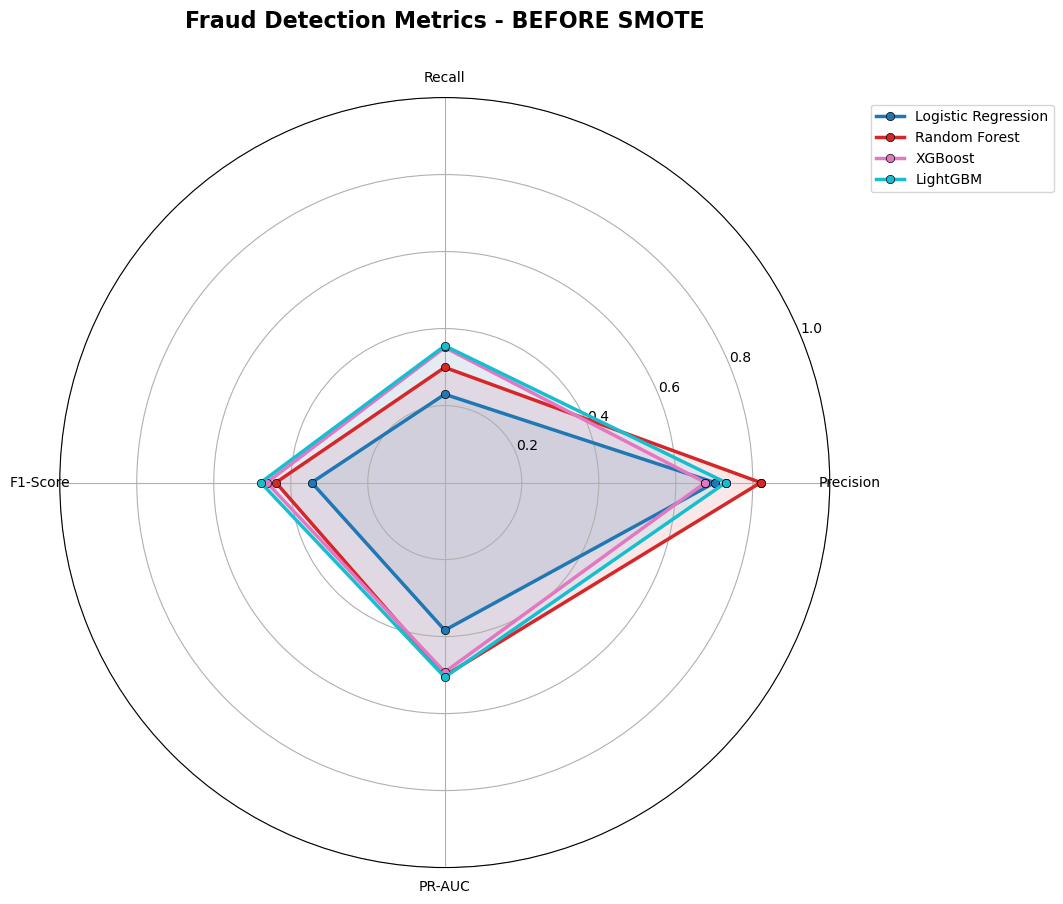

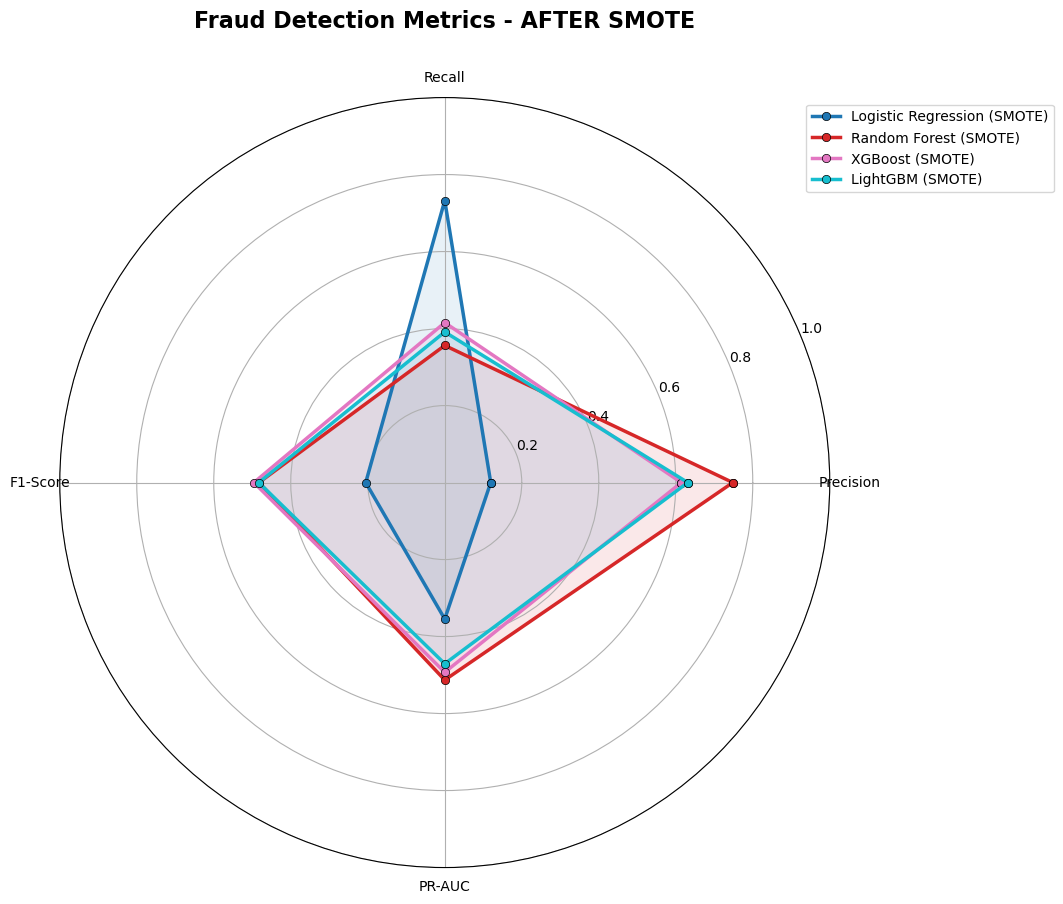

In [108]:
# 4. RADAR CHART COMPARISON for key fraud metrics
from math import pi

# Radar chart function
def create_radar_chart(models, metrics_dict, title):
    categories = list(metrics_dict.keys())
    N = len(categories)
    
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    
    for i, (model, metrics) in enumerate(models):
        values = [metrics[cat] for cat in categories]
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2.5, label=model, color=colors[i], 
        markersize=6, markeredgecolor='black', markeredgewidth=0.5)
        ax.fill(angles, values, alpha=0.1, color=colors[i])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories)
    ax.set_ylim(0, 1)
    ax.set_title(title, size=16, fontweight='bold', y=1.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    return fig

# Prepare data for radar chart
fraud_metrics = ['Precision', 'Recall', 'F1-Score', 'PR-AUC']

# Before SMOTE
models_before = []
for i, row in baseline_metrics.iterrows():
    model_metrics = {metric: row[metric] for metric in fraud_metrics}
    models_before.append((row['Model'], model_metrics))

# After SMOTE  
models_after = []
for i, row in sm_baseline.iterrows():
    model_metrics = {metric: row[metric] for metric in fraud_metrics}
    models_after.append((row['Model'], model_metrics))

# Create radar charts
create_radar_chart(models_before, {m: m.replace('_Fraud', '') for m in fraud_metrics}, 
                  'Fraud Detection Metrics - BEFORE SMOTE')
plt.savefig("baseline_fraudWO_metrics_radar.png", dpi=300, facecolor='white')
plt.show()

create_radar_chart(models_after, {m: m.replace('_Fraud', '') for m in fraud_metrics}, 
                  'Fraud Detection Metrics - AFTER SMOTE')
plt.savefig("smote_fraud_metricsWO_radar.png", dpi=300, facecolor='white')
plt.show()

